# 01 · Corpus travail-emploi : chargement depuis la source et découpages comparés

**Ticket #35.** Ce notebook part des documents complets publiés par SocialGouv, en extrait un texte
structuré accompagné de ses métadonnées de citation, puis construit quatre découpages comparables.

| Méthode | Principe |
|---|---|
| M0 | découpage de l'éditeur (jeu Hugging Face), filtré comme la PR #32 : la référence à battre |
| M1 | fenêtre fixe de tokens avec chevauchement, sans égard à la structure du texte |
| M2 | découpage structurel depuis le html : sections, intertitres, paragraphes, listes, tableaux |
| M3 | découpage sémantique : coupure là où deux phrases voisines s'éloignent en sens |

Ce notebook **ne calcule aucun index** : il produit les fichiers de passages que le notebook
d'indexation encodera. Il ne mesure pas non plus la qualité de recherche, qui exige un jeu de questions :
il mesure des **indicateurs intrinsèques** (taille, coupures, couverture, redondance).

Règle suivie dans tout le notebook : une affirmation n'est écrite que si une cellule la vérifie,
par une mesure affichée ou par une assertion qui arrête l'exécution en cas d'écart.

**Sommaire**
1. Configuration et reproductibilité
2. Sources figées et contrôle d'empreinte
3. Schéma réel des données
4. Sélection des 261 fiches et métadonnées de fiche
5. Du html aux blocs typés
6. Réparations, filtres et exclusions
7. Contrôles de couverture
8. Métadonnées de citation
9. Outils communs : tokeniseur et découpeur de phrases
10. M0, découpage de l'éditeur
11. M2, découpage structurel
12. M1, fenêtre fixe
13. M3, découpage sémantique
14. Comparaison intrinsèque
15. Export pour l'indexation

## 1. Configuration et reproductibilité

**Environnement.** Le notebook s'exécute dans le `.venv` de la racine du dépôt, en Python 3.12, construit à
l'identique depuis le fichier figé des dépendances :

```
uv venv --seed --python 3.12 .venv
uv pip sync --python .venv/bin/python scripts/decoupage/requirements-lock.txt
```

Dans VS Code : *Select Kernel*, *Python Environments*, `.venv`. Un noyau Jupyter global nommé « python3 » peut
pointer vers un tout autre environnement : la première cellule affiche l'interpréteur réellement utilisé.
Le premier lancement télécharge le modèle de M3 (470 Mio) dans le cache Hugging Face, hors du dépôt.

Tous les chemins sont calculés depuis la racine du dépôt, pour que le notebook s'exécute de la même façon
depuis VS Code, Jupyter ou la ligne de commande. Les données produites vont dans `data/decoupage/`, que git
ignore : la cellule le **vérifie** avant d'écrire quoi que ce soit.

In [1]:
import os
import warnings

# barres de progression des bibliothèques Hugging Face : sans intérêt dans ce notebook, et bruyantes sans ipywidgets
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
warnings.filterwarnings("ignore", message="IProgress not found")

import hashlib
import json
import platform
import random
import re
import shutil
import subprocess
import sys
import time
import urllib.request
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import quote

import bs4
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tokenizers
from bs4 import BeautifulSoup, NavigableString
from bs4.element import CData, Comment, Declaration, Doctype, ProcessingInstruction
from lxml import etree
from tokenizers import Tokenizer

try:
    display
except NameError:  # exécution hors Jupyter : affichage texte
    def display(objet):
        """Affichage de repli quand le code tourne hors de Jupyter."""
        print(objet.to_string() if isinstance(objet, pd.DataFrame) else objet)

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 220)
GRAINE = 20260927
random.seed(GRAINE)
np.random.seed(GRAINE)


def racine_depot(depart: Path) -> Path:
    """Remonte les dossiers parents jusqu'à la racine du dépôt git, celle qui contient .git."""
    for dossier in (depart, *depart.parents):
        if (dossier / ".git").exists():
            return dossier
    raise FileNotFoundError(f"aucun dépôt git au-dessus de {depart}")


RACINE = racine_depot(Path.cwd().resolve())
DONNEES = RACINE / "data" / "decoupage"
SOURCES = DONNEES / "sources"
SORTIES = DONNEES / "passages"
CACHE = DONNEES / "cache"
for dossier in (SOURCES, SORTIES, CACHE):
    dossier.mkdir(parents=True, exist_ok=True)

ignore = subprocess.run(["git", "-C", str(RACINE), "check-ignore", "-q", str(DONNEES)]).returncode == 0
assert ignore, "data/decoupage n'est pas ignoré par git : corriger l'exclusion avant d'aller plus loin"

VERSIONS = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "beautifulsoup4": bs4.__version__,
    "lxml": etree.__version__,
    "tokenizers": tokenizers.__version__,
    "matplotlib": matplotlib.__version__,
}
print("interpréteur :", sys.executable)
assert sys.version_info[:2] == (3, 12), f"Python {platform.python_version()} : le notebook est validé en Python 3.12"
if Path(sys.prefix).resolve() != (RACINE / ".venv").resolve():
    print("attention : l'interpréteur n'est pas le .venv du dépôt ; les versions peuvent différer de requirements-lock.txt")
print("racine du dépôt :", RACINE)
print("données (ignorées par git) :", DONNEES.relative_to(RACINE))
print(VERSIONS)

interpréteur : /Users/mahe/Desktop/M1_DTA/NLP_PROJET/data_tigers_nlp/.venv/bin/python
racine du dépôt : /Users/mahe/Desktop/M1_DTA/NLP_PROJET/data_tigers_nlp
données (ignorées par git) : data/decoupage
{'python': '3.12.11', 'pandas': '3.0.6', 'numpy': '2.5.3', 'beautifulsoup4': '4.15.0', 'lxml': '6.1.3', 'tokenizers': '0.23.2', 'matplotlib': '3.11.2'}


**Paramètres.** Ils sont tous regroupés ici ; les sections suivantes n'en introduisent aucun autre.
Le budget de 512 tokens est la longueur maximale de l'encodeur, tokens spéciaux et préfixe `passage: ` compris :
au-delà, l'encodeur tronque silencieusement la fin du passage.

In [2]:
BUDGET = 512                     # tokens, préfixe et tokens spéciaux compris
PREFIXE = "passage: "            # préfixe E5 des passages (celui des requêtes est « query: »)
REPARER = True                   # réparer les espaces ajoutées par le scraper (section 6)
GARDER_RETRANSCRIPTIONS = True   # garder les retranscriptions de vidéos (section 6)
M2_MIN_TOKENS = 64               # M2 : taille sous laquelle un intertitre ne ferme pas le passage en cours
M1_CHEVAUCHEMENT = 0.20          # M1 : part de la fenêtre reprise dans la fenêtre suivante
M3_VOISINAGE = 1                 # M3 : phrases voisines ajoutées de chaque côté pour l'encodage
M3_MIN_TOKENS = 64               # M3 : pas de coupure sémantique avant cette taille (min_chunk_size de LangChain)
MARGE_M3 = 16                    # M3 : marge de sécurité sur l'estimation additive des tokens
TOLERANCE_TAILLE = 0.02          # M1 et M3 : écart relatif toléré avec la taille moyenne cible

**Pour la soutenance.**

- Tous les chemins partent de la racine du dépôt ; les données vont dans `data/`, et la cellule vérifie que git les ignore.
- La première sortie affiche l'interpréteur : il doit s'agir du `.venv` du dépôt, un noyau global pouvant pointer ailleurs.
- Tous les paramètres sont réunis dans une seule cellule : aucun réglage n'est caché plus loin.

## 2. Sources figées et contrôle d'empreinte

Deux sources, chacune figée sur un commit et contrôlée par son empreinte SHA-256 :

- **SocialGouv/fiches-travail-data**, la source amont : les fiches complètes du site travail-emploi.gouv.fr,
  avec leur html. Le dépôt est mis à jour chaque nuit ; le commit fbf639f du 11/09/2026 est contemporain de
  l'instantané Hugging Face retenu au jalon J2.
- **AgentPublic/travail-emploi**, le jeu Hugging Face : il donne la liste des 261 fiches retenues et le
  découpage de l'éditeur, qui sert de référence M0.

Si un fichier présent localement n'a pas l'empreinte attendue, il est retéléchargé ; si l'empreinte du
téléchargement diffère encore, le notebook s'arrête.

In [3]:
SOURCE_SG = {
    "depot": "SocialGouv/fiches-travail-data",
    "commit": "fbf639f9cd5f2be87739e1ec2da42d8724af4190",
    "chemin": "data/fiches-travail.json",
    "sha256": "1b648d1174ebfd88769d89e7d3ce1dc87a5880b97ab7d23c068fc6ff96adf028",
    "licence": "Apache-2.0 (code) ; contenu : site travail-emploi.gouv.fr",
}
SOURCE_SG["url"] = f"https://raw.githubusercontent.com/{SOURCE_SG['depot']}/{SOURCE_SG['commit']}/{SOURCE_SG['chemin']}"
SOURCE_HF = {
    "depot": "AgentPublic/travail-emploi",
    "commit": "98744a63d40d982ff8b5345ca635ad543a412163",
    "chemin": "data/travail-emploi-20260911/travail_emploi_part_0.parquet",
    "sha256": "b76ab4c4408b737fadaade549dfa7734ec9b3343b7c19f0285cf3c6cd858ef4f",
    "licence": "Etalab 2.0",
}
SOURCE_HF["url"] = f"https://huggingface.co/datasets/{SOURCE_HF['depot']}/resolve/{SOURCE_HF['commit']}/{SOURCE_HF['chemin']}"
TOKENISEUR = {"depot": "Xenova/multilingual-e5-small", "revision": "761b726dd34fb83930e26aab4e9ac3899aa1fa78"}
MODELE_M3 = {"depot": "intfloat/multilingual-e5-small", "revision": "614241f622f53c4eeff9890bdc4f31cfecc418b3"}


def sha256_fichier(chemin: Path) -> str:
    """Empreinte SHA-256 d'un fichier, lue par blocs de 1 Mio pour ne pas le charger en mémoire."""
    h = hashlib.sha256()
    with open(chemin, "rb") as f:
        for bloc in iter(lambda: f.read(1 << 20), b""):
            h.update(bloc)
    return h.hexdigest()


def obtenir(source: dict, destination: Path) -> str:
    """Garantit une source à l'empreinte attendue : copie locale réutilisée si elle est conforme, sinon téléchargement dans un fichier partiel, vérifié avant d'être mis en place."""
    if destination.exists() and sha256_fichier(destination) == source["sha256"]:
        return "présent, empreinte conforme"
    partiel = destination.with_name(destination.name + ".partiel")
    with urllib.request.urlopen(source["url"], timeout=300) as reponse, open(partiel, "wb") as f:
        shutil.copyfileobj(reponse, f)
    empreinte = sha256_fichier(partiel)
    if empreinte != source["sha256"]:
        partiel.unlink()
        raise ValueError(f"empreinte inattendue pour {source['url']} : {empreinte}")
    partiel.replace(destination)
    return "téléchargé, empreinte conforme"


FICHIER_SG = SOURCES / f"fiches-travail_{SOURCE_SG['commit'][:7]}.json"
FICHIER_HF = SOURCES / f"travail-emploi_{SOURCE_HF['commit'][:7]}.parquet"
for source, fichier in ((SOURCE_SG, FICHIER_SG), (SOURCE_HF, FICHIER_HF)):
    etat = obtenir(source, fichier)
    print(f"{source['depot']:32} {fichier.stat().st_size / 2**20:6.1f} Mio  {etat}")

SocialGouv/fiches-travail-data     16.4 Mio  présent, empreinte conforme
AgentPublic/travail-emploi         29.6 Mio  présent, empreinte conforme


**Pour la soutenance.**

- Deux sources figées sur un commit et contrôlées par empreinte SHA-256 : on sait exactement quel texte a été traité.
- Un téléchargement n'est mis en place qu'après contrôle de son empreinte : jamais de fichier corrompu utilisé.

## 3. Schéma réel des données

Le dépôt SocialGouv déclare un schéma dans `src/types.ts`. On ne s'y fie pas : on recense les clés
réellement présentes à chaque niveau (fiche, section, référence, article) et on les compare au schéma déclaré.

Ce que le code du scraper (`src/fetch-data/parseDom.js`, même commit) apprend sur ces champs, et qui
conditionne tout le reste :

- une **section** est ce qui suit un intertitre `h2` jusqu'au `h2` suivant ; `html` et `text` en sont deux
  rendus. `text` concatène le texte des éléments **sans séparateur** : un intertitre y est collé au paragraphe
  suivant (« obligatoires ?Le salarié »). D'où la décision de découper depuis `html` ;
- `anchor` **n'est pas un identifiant lu sur le site** : c'est un slug calculé à partir du titre de section.
  Vérifié le 27/09/2026 sur la page « Le bulletin de paie » : les intertitres du site portent des identifiants
  `anchor-navigation-NNN` tirés au hasard à chaque chargement (772 puis 605 pour le même intertitre).
  Un lien `url#anchor` ne pointe donc sur rien (section 8) ;
- `references` est **extrait automatiquement** du texte par expressions régulières puis résolu dans la base
  Légifrance ; un article dont le code n'est pas reconnu est rattaché par défaut au Code du travail ;
- `description` d'une section n'est que les 200 premiers caractères de son texte ;
- les adresses électroniques sont masquées (`@` devient `_@`) pour gêner leur collecte.

In [4]:
fiches_sg = json.loads(FICHIER_SG.read_text(encoding="utf-8"))
hf = pd.read_parquet(FICHIER_HF)
print(f"SocialGouv : {len(fiches_sg)} fiches | Hugging Face : {len(hf)} passages, {hf.doc_id.nunique()} fiches")

DECLARE = {
    "fiche": {"date", "description", "intro", "pubId", "sections", "title", "url"},
    "section": {"anchor", "description", "html", "references", "text", "title"},
    "référence (code)": {"name", "articles"},
    "article": {"id", "cid", "fmt", "text"},
}
toutes_sections = [s for f in fiches_sg for s in f["sections"]]
toutes_refs = [v for s in toutes_sections for v in s["references"].values()]
tous_articles = [a for v in toutes_refs for a in v["articles"]]


def ecarts_au_schema(niveau, objets):
    """Compare les jeux de clés réellement présents au schéma déclaré par SocialGouv : une ligne par combinaison observée."""
    declare = DECLARE[niveau]
    return [{"niveau": niveau, "objets": n, "clés manquantes": ", ".join(sorted(declare - set(cles))) or "aucune",
             "clés non déclarées": ", ".join(sorted(set(cles) - declare)) or "aucune"}
            for cles, n in Counter(frozenset(o) for o in objets).most_common()]


display(pd.DataFrame([ligne for niveau, objets in (("fiche", fiches_sg), ("section", toutes_sections),
                                                   ("référence (code)", toutes_refs), ("article", tous_articles))
                      for ligne in ecarts_au_schema(niveau, objets)]))

SocialGouv : 270 fiches | Hugging Face : 5702 passages, 261 fiches


,niveau,objets,clés manquantes,clés non déclarées
0,fiche,270,aucune,aucune
1,section,2231,aucune,aucune
2,référence (code),844,aucune,aucune
3,référence (code),205,name,aucune
4,article,8715,text,aucune
5,article,4575,aucune,aucune
6,article,410,"cid, id",aucune


Lecture : les fiches et les sections respectent le schéma ; les références et les articles non. Des codes
n'ont pas de `name` (références non résolues, clé `UNDEFINED`), et des articles n'ont pas de `text` : ce sont
les articles intermédiaires d'une plage « L. 1234-9 à L. 1234-11 » que le résolveur déplie. Tout code qui lit
ces champs doit donc tolérer leur absence.

**Pour la soutenance.**

- On ne se fie pas au schéma déclaré : on compte les clés réellement présentes, et des champs manquent.
- Trois pièges lus dans le code du scraper : `text` colle les intertitres, `anchor` est un slug absent du site, les références sont extraites par heuristique.

## 4. Sélection des 261 fiches et métadonnées de fiche

Le jeu Hugging Face contient 261 fiches ; SocialGouv en contient davantage. On retient exactement les 261
fiches du jeu Hugging Face, pour que toutes les méthodes portent sur le même périmètre que M0.

**Piège mesuré :** la jointure doit se faire sur l'identifiant (`pubId` côté SocialGouv, `doc_id` côté
Hugging Face), pas sur l'URL. Plusieurs URL figurent deux fois dans SocialGouv, sous deux identifiants différents.

In [5]:
ordre_hf = list(dict.fromkeys(hf.doc_id))
par_id = {f["pubId"]: f for f in fiches_sg}
assert len(par_id) == len(fiches_sg), "pubId non unique dans SocialGouv"

urls_hf = set(hf.url)
compte_url = Counter(f["url"] for f in fiches_sg)
print("fiches SocialGouv retrouvées par URL :", sum(f["url"] in urls_hf for f in fiches_sg))
print("fiches SocialGouv retrouvées par identifiant :", sum(i in par_id for i in ordre_hf), "/", len(ordre_hf))
jumeaux = []
for url in sorted(u for u, n in compte_url.items() if n > 1):
    paire = [f for f in fiches_sg if f["url"] == url]
    identiques = all(a["html"] == b["html"] for a, b in zip(paire[0]["sections"], paire[1]["sections"]))
    jumeaux.append({"url": url.removeprefix("https://travail-emploi.gouv.fr/")[:60],
                    "pubId": " / ".join(f["pubId"] for f in paire),
                    "retenu (présent dans HF)": next(f["pubId"] for f in paire if f["pubId"] in set(ordre_hf)),
                    "sections identiques": identiques})
display(pd.DataFrame(jumeaux))

fiches = [par_id[i] for i in ordre_hf]
assert len(fiches) == 261 and len({f["pubId"] for f in fiches}) == 261

fiches SocialGouv retrouvées par URL : 265
fiches SocialGouv retrouvées par identifiant : 261 / 261


,url,pubId,retenu (présent dans HF),sections identiques
0,la-certification-des-competences-des-representants-du-person,article376824 / article376837,article376824,True
1,le-conge-ou-temps-partiel-pour-creation-ou-reprise-dune-jeun,article101169 / article374527,article101169,True
2,le-projet-de-transition-professionnelle,article374461 / article377017,article374461,True
3,lobligation-demploi-des-travailleurs-handicapes-oeth,article201165 / article377254,article201165,True


**Métadonnées de fiche.** Titre, URL et date de mise à jour sont recopiés sur chaque passage : ils servent à
afficher la source et à la dater. On vérifie qu'ils concordent avec ceux du jeu Hugging Face. La date est celle
de la mention « Mis à jour le » de la page, à défaut « Publié le » (code du scraper, fonction `getDate`) ;
on la convertit au format ISO.

In [6]:
meta_hf = hf.drop_duplicates("doc_id").set_index("doc_id")


def texte_html(fragment: str) -> str:
    """Texte visible d'un fragment html, espaces réduites : sert aux comparaisons avec le jeu Hugging Face."""
    return re.sub(r"\s+", " ", BeautifulSoup(fragment, "lxml").get_text(" ")).strip()


def sans_espaces(texte: str) -> str:
    """Réduit toute suite d'espaces, de tabulations ou de sauts de ligne à une seule espace."""
    return re.sub(r"\s+", " ", texte).strip()


def alnum(texte: str) -> str:
    """Lettres et chiffres seuls, en minuscules : sert à comparer deux textes sans tenir compte des espaces ni de la ponctuation."""
    return re.sub(r"[\W_]+", "", texte).lower()


chapo_sg = {f["pubId"]: texte_html(f["intro"]) for f in fiches}
chapo_hf = {f["pubId"]: sans_espaces(meta_hf.loc[f["pubId"], "introduction"]) for f in fiches}
concordance = pd.Series({
    "titre identique": sum(f["title"] == meta_hf.loc[f["pubId"], "title"] for f in fiches),
    "URL identique": sum(f["url"] == meta_hf.loc[f["pubId"], "url"] for f in fiches),
    "date identique": sum(f["date"] == meta_hf.loc[f["pubId"], "date"] for f in fiches),
    "chapô identique à `introduction`": sum(chapo_sg[p] == chapo_hf[p] for p in chapo_sg),
    "chapô identique, points de suspension normalisés": sum(chapo_sg[p].replace("\u2026", "...") == chapo_hf[p] for p in chapo_sg),
    "fiches sans chapô": sum(not f["intro"].strip() for f in fiches),
}, name=f"sur {len(fiches)} fiches")
display(concordance.to_frame())

df_fiches = pd.DataFrame([{
    "pubId": f["pubId"], "titre": f["title"], "url": f["url"],
    "date_maj": datetime.strptime(f["date"], "%d/%m/%Y").date().isoformat(),
    "description": f["description"], "sections_sg": len(f["sections"]), "chapo": bool(f["intro"].strip()),
} for f in fiches]).set_index("pubId")
print("dates de mise à jour : de", df_fiches.date_maj.min(), "à", df_fiches.date_maj.max())
display(df_fiches.drop(columns="description").head(3))

,sur 261 fiches
titre identique,261
URL identique,261
date identique,261
chapô identique à `introduction`,240
"chapô identique, points de suspension normalisés",261
fiches sans chapô,7


dates de mise à jour : de 2008-11-17 à 2026-08-27


,titre,url,date_maj,sections_sg,chapo
pubId,,,,,
12399,Burn-out et risques psychosociaux : comprendre pour mieux prévenir,https://travail-emploi.gouv.fr/burn-out-et-risques-psychosociaux-comprendre-pour-mieux-prevenir,2025-06-12,6,True
12509,La période de reconversion,https://travail-emploi.gouv.fr/la-periode-de-reconversion,2026-03-05,18,True
12510,L'adaptation du poste du salarié à sa situation,https://travail-emploi.gouv.fr/adapter-le-poste-dun-salarie-sa-situation,2025-11-04,11,True


**Pour la soutenance.**

- La jointure se fait sur l'identifiant (261 fiches), pas sur l'URL (265, à cause de quatre fiches en double).
- Titre, URL et date concordent avec le jeu Hugging Face ; le chapô aussi, aux points de suspension près.

## 5. Du html aux blocs typés

Le html de chaque section est parcouru **dans l'ordre de lecture** et converti en blocs typés :
intertitre, paragraphe, élément de liste, ligne de tableau. Chaque bloc garde son **chemin**, la suite des
intertitres sous lesquels il se trouve. C'est l'extraction commune à M1, M2 et M3.

Le site utilise le système de design de l'État (DSFR). L'inventaire des composants présents dans les 261 fiches
a guidé les règles suivantes, chacune justifiée par une mesure :

| Composant | Traitement | Pourquoi |
|---|---|---|
| `fr-card` (carte) | exclu, texte conservé pour contrôle | aperçu tronqué d'une autre fiche, présent dans les sections de liens mais aussi ailleurs |
| `fr-accordion` (accordéon) | titre traité comme un intertitre, contenu parcouru dessous | il contient notamment les retranscriptions de vidéos |
| `fr-callout`, `fr-highlight` | parcourus normalement, composant noté | encadrés et mises en exergue : du contenu ordinaire |
| `table` | une ligne de tableau par bloc, chaque cellule préfixée de son en-tête de colonne | une ligne reste lisible seule, même séparée des autres |
| `h2` à l'intérieur d'une section | ouvre une nouvelle section | le scraper a parfois aggloméré plusieurs sections en une |
| `img`, `script`, `style`, `iframe` | ignorés | aucun texte affiché |

Le texte d'un élément est reconstitué **sans ajouter de séparateur entre éléments en ligne** : sinon « 1<sup>er</sup> »
deviendrait « 1 er ». Un saut de ligne est inséré seulement entre éléments de bloc et à la place de `<br>`.

In [7]:
TITRES = {f"h{i}": i for i in range(1, 7)}
EN_LIGNE = {"a", "abbr", "b", "bdi", "bdo", "button", "cite", "code", "data", "del", "dfn", "em", "font", "i",
            "ins", "kbd", "label", "mark", "q", "s", "samp", "small", "span", "strong", "sub", "sup", "time", "u",
            "var", "wbr"}
IGNORES = {"script", "style", "noscript", "img", "picture", "svg", "iframe", "video", "audio", "source", "input",
           "form", "hr"}
BLOCS_HTML = {"address", "article", "aside", "blockquote", "caption", "dd", "div", "dl", "dt", "figcaption",
              "figure", "footer", "h1", "h2", "h3", "h4", "h5", "h6", "header", "li", "main", "nav", "ol", "p", "pre",
              "section", "table", "tbody", "td", "tfoot", "th", "thead", "tr", "ul"}
NON_TEXTE = (Comment, CData, Declaration, Doctype, ProcessingInstruction)
RE_RETRANSCRIPTION = re.compile(r"retranscription", re.I)
ESPACES = str.maketrans({"\u00a0": " ", "\u202f": " ", "\u2009": " ", "\t": " ", "\r": "",
                         "\u200b": "", "\u200c": "", "\u200d": "", "\ufeff": ""})   # espaces insécables, caractères invisibles


def normaliser(texte: str) -> str:
    """Espaces insécables et tabulations en espaces, caractères invisibles supprimés, espaces multiples réduites, lignes vides supprimées."""
    lignes = (re.sub(r" {2,}", " ", ligne).strip() for ligne in texte.translate(ESPACES).split("\n"))
    return "\n".join(ligne for ligne in lignes if ligne)


# Réparations des espaces que la fonction textClean du scraper insère après chaque « . », « ! » ou « ? ».
# Seuls des motifs où l'espace ne peut pas être d'origine sont réparés (section 6 : exemples tirés au hasard).
REPARATIONS = {
    "nombre coupé (23-21. 640)": (re.compile(r"(?<=\d)\. (?=\d)"), "."),
    "nom de domaine (gouv. fr)": (re.compile(r"(?<=[A-Za-z0-9-])\. (?=(?:fr|gouv|org|net|eu|html?|php|pdf|aspx?|xlsx?|docx?|odt)\b)"), "."),
    "préfixe web (www. )": (re.compile(r"(?<=\bwww)\. "), "."),
    "courriel masqué (_@)": (re.compile(r"_@"), "@"),
}
REPARATIONS_FAITES = defaultdict(list)


def reparer(texte: str) -> str:
    """Applique les réparations sûres de REPARATIONS et garde le contexte de chacune, pour la relecture de la section 6."""
    if not REPARER:
        return texte
    for nom, (motif, remplacement) in REPARATIONS.items():
        for m in motif.finditer(texte):
            REPARATIONS_FAITES[nom].append(texte[max(0, m.start() - 30):m.end() + 30])
        texte = motif.sub(remplacement, texte)
    return texte


def propre(texte: str) -> str:
    """Normalisation puis réparation : la forme de texte utilisée partout dans l'extraction."""
    return reparer(normaliser(texte))


@dataclass
class Bloc:
    """Unité élémentaire de texte extraite du html : type, texte, place dans la hiérarchie des intertitres, éventuel motif d'exclusion."""
    type: str                    # intertitre, paragraphe, élément de liste, ligne de tableau, titre de section, exclu
    texte: str                   # texte du bloc tel qu'il entrera dans un passage
    page: str = ""               # texte tel qu'affiché sur la page (sans marque de liste), pour contrôles et liens
    niveau: int = 0              # niveau d'intertitre, ou profondeur de liste
    chemin: tuple = ()           # intertitres en vigueur au-dessus du bloc
    composant: str = ""          # accordéon, encadré, mise en exergue, ou vide
    retranscription: bool = False
    groupe: int = -1             # identifiant de la liste ou du tableau d'appartenance
    exclu: str = ""              # motif d'exclusion ; vide si le bloc est conservé
    accordeon: str = ""          # titre de l'accordéon englobant : son contenu est masqué tant qu'on ne le déplie pas


class Extracteur:
    """Parcourt le html d'une section dans l'ordre de lecture et le convertit en blocs typés."""

    def __init__(self):
        """État du parcours : blocs produits, pile d'intertitres, composants et accordéons en cours, texte en ligne en attente."""
        self.blocs, self.pile, self.composants, self.tampon, self.accordeons = [], [], [], [], []
        self.retranscription, self.groupe = False, 0

    def chemin(self):
        """Intertitres en vigueur au point courant, du plus général au plus précis."""
        return tuple(titre for _, titre in self.pile)

    def ajouter(self, type_, texte, page=None, **attributs):
        """Ajoute un bloc nettoyé, avec le chemin, le composant, l'accordéon et le drapeau de retranscription en cours."""
        texte = propre(texte)
        if texte:
            self.blocs.append(Bloc(type_, texte, texte if page is None else propre(page), chemin=self.chemin(),
                                   composant=self.composants[-1] if self.composants else "",
                                   retranscription=self.retranscription,
                                   accordeon=self.accordeons[-1] if self.accordeons else "", **attributs))

    def exclure(self, motif, element):
        """Enregistre un élément exclu, comme une carte de lien, sous forme de bloc exclu : les contrôles de couverture en tiennent compte."""
        texte = propre(self.texte(element))
        if texte:
            self.blocs.append(Bloc("exclu", texte, texte, chemin=self.chemin(), exclu=motif))

    def texte(self, element, sauf=()):
        """Texte d'un élément : éléments en ligne concaténés, saut de ligne entre éléments de bloc."""
        morceaux = []

        def visiter(noeud):
            """Parcours récursif du sous-arbre de l'élément."""
            for enfant in noeud.children:
                if isinstance(enfant, NON_TEXTE):
                    continue
                if isinstance(enfant, NavigableString):
                    morceaux.append(str(enfant))
                    continue
                if enfant.name in IGNORES or enfant.name in sauf:
                    continue
                if "fr-card" in (enfant.get("class") or []):
                    self.exclure("carte de lien", enfant)
                    continue
                if enfant.name == "br":
                    morceaux.append("\n")
                    continue
                bloc = enfant.name in BLOCS_HTML
                morceaux.append("\n" if bloc else "")
                visiter(enfant)
                morceaux.append("\n" if bloc else "")

        visiter(element)
        return "".join(morceaux)

    def vider_tampon(self):
        """Transforme en paragraphe le texte en ligne accumulé directement dans un conteneur."""
        if self.tampon:
            self.ajouter("paragraphe", "".join(self.tampon))
            self.tampon = []

    def parcourir(self, noeud):
        """Parcourt les enfants d'un noeud et aiguille chacun selon sa nature : carte, accordéon, encadré, titre, paragraphe, liste, tableau ou simple conteneur."""
        for enfant in noeud.children:
            if isinstance(enfant, NON_TEXTE):
                continue
            if isinstance(enfant, NavigableString):
                self.tampon.append(str(enfant))
                continue
            nom, classes = enfant.name, set(enfant.get("class") or [])
            # aiguillage : l'ordre des tests compte, un composant DSFR prime sur la balise qui le porte
            if "fr-card" in classes:
                self.vider_tampon()
                self.exclure("carte de lien", enfant)
            elif nom in IGNORES:
                continue
            elif nom == "br":
                self.tampon.append("\n")
            elif nom in EN_LIGNE:
                self.tampon.append(self.texte(enfant))
            else:
                self.vider_tampon()
                if "fr-accordion" in classes:
                    self.accordeon(enfant)
                elif "fr-callout" in classes:
                    self.portee(enfant, "encadré")
                elif "fr-highlight" in classes:
                    self.portee(enfant, "mise en exergue")
                elif nom in TITRES:
                    self.titre(enfant)
                elif nom == "p":
                    self.ajouter("paragraphe", self.texte(enfant))
                elif nom in ("ul", "ol"):
                    self.liste(enfant, 0, None)
                elif nom == "table":
                    self.tableau(enfant)
                else:
                    self.parcourir(enfant)
        self.vider_tampon()

    def titre(self, element):
        """Traite un intertitre : un h2 ouvre une nouvelle section, un h3 à h6 met à jour la pile des intertitres."""
        texte = propre(self.texte(element)).replace("\n", " ")
        if not texte:
            return
        niveau = TITRES[element.name]
        if niveau <= 2:
            self.pile = []
            self.blocs.append(Bloc("titre de section", texte, texte, niveau=niveau))
            return
        while self.pile and self.pile[-1][0] >= niveau:
            self.pile.pop()
        self.ajouter("intertitre", texte, niveau=niveau)
        self.pile.append((niveau, texte))

    def accordeon(self, element):
        """Traite un accordéon DSFR : son titre devient un intertitre, son contenu est parcouru dessous, une retranscription de vidéo est signalée."""
        entete = element.select_one(".fr-accordion__title") or element.select_one(".fr-accordion__btn")
        titre = propre(self.texte(entete)).replace("\n", " ") if entete else ""
        if entete:
            entete.extract()
        pile, retranscription = list(self.pile), self.retranscription
        niveau = self.pile[-1][0] + 1 if self.pile else 3
        if titre:
            self.ajouter("intertitre", titre, niveau=niveau)
            self.pile.append((niveau, titre))
        self.retranscription = retranscription or bool(RE_RETRANSCRIPTION.search(titre))
        self.accordeons.append(titre)
        self.portee(element, "accordéon")
        self.accordeons.pop()
        self.pile, self.retranscription = pile, retranscription

    def portee(self, element, nom):
        """Parcourt un composant (encadré, mise en exergue, accordéon), puis restaure la pile des intertitres."""
        pile = list(self.pile)
        self.composants.append(nom)
        self.parcourir(element)
        self.composants.pop()
        self.pile = pile

    def liste(self, element, profondeur, groupe):
        """Traite une liste en respectant l'ordre du html, même quand du texte suit une sous-liste dans un même élément."""
        if groupe is None:
            self.groupe += 1
            groupe = self.groupe
        ordonnee = element.name == "ol"
        for rang, item in enumerate(element.find_all("li", recursive=False), 1):
            morceaux, premier = [], True

            def emettre():
                """Émet le texte accumulé de l'élément de liste courant."""
                nonlocal morceaux, premier
                texte = propre("".join(morceaux)).replace("\n", " ")
                if texte:
                    # la suite d'un élément après une sous-liste garde son niveau, sans nouvelle marque
                    marque = (f"{rang}. " if ordonnee else "- ") if premier else ""
                    self.ajouter("élément de liste", marque + texte, page=texte, niveau=profondeur, groupe=groupe)
                    premier = False
                morceaux = []

            for enfant in item.children:
                if getattr(enfant, "name", None) in ("ul", "ol"):
                    emettre()
                    self.liste(enfant, profondeur + 1, groupe)
                elif getattr(enfant, "name", None) and "fr-card" in (enfant.get("class") or []):
                    # texte() ne regarde que les enfants de l'élément reçu : une carte posée directement dans
                    # l'élément de liste doit donc être reconnue ici, sans quoi son aperçu entrerait comme contenu
                    emettre()
                    self.exclure("carte de lien", enfant)
                elif isinstance(enfant, NON_TEXTE):
                    continue
                elif isinstance(enfant, NavigableString):
                    morceaux.append(str(enfant))
                else:
                    bloc = enfant.name in BLOCS_HTML
                    morceaux.append(("\n" if bloc else "") + self.texte(enfant, sauf={"ul", "ol"}) + ("\n" if bloc else ""))
                    internes = [l for l in enfant.find_all(["ul", "ol"]) if l.find_parent("li") is item]
                    if internes:
                        emettre()
                        for sous_liste in internes:
                            self.liste(sous_liste, profondeur + 1, groupe)
            emettre()

    def tableau(self, element):
        """Traite un tableau : une ligne par bloc, chaque cellule préfixée de l'en-tête de sa colonne."""
        self.groupe += 1
        legende = element.find("caption")
        if legende:
            self.ajouter("paragraphe", self.texte(legende))
            legende.extract()
        entetes = None
        for ligne in element.find_all("tr"):
            if ligne.find_parent("table") is not element:
                continue
            cellules = ligne.find_all(["th", "td"], recursive=False)
            textes = [propre(self.texte(c)).replace("\n", " ") for c in cellules]
            if not any(textes):
                continue
            if entetes is None and all(c.name == "th" for c in cellules):
                entetes = textes
                self.blocs.append(Bloc("en-tête de tableau", " | ".join(textes), " ".join(textes),
                                       chemin=self.chemin(), groupe=self.groupe, exclu="en-tête repris dans chaque ligne"))
                continue
            if entetes and len(entetes) == len(textes):
                serie = " ; ".join(f"{h} : {t}" if h else t for h, t in zip(entetes, textes) if t)
            else:
                serie = " | ".join(t for t in textes if t)
            self.ajouter("ligne de tableau", serie, page=" ".join(t for t in textes if t), groupe=self.groupe)


def corps(fragment: str):
    """Analyse un fragment html avec lxml et renvoie son élément body, ou le document entier à défaut."""
    soupe = BeautifulSoup(fragment, "lxml")
    return soupe.body if soupe.body else soupe


# Démonstration sur une section courte de la fiche « Le bulletin de paie »
demo = next(s for s in par_id["article374540"]["sections"] if normaliser(s["title"]) == "Et les mentions interdites ?")
ex = Extracteur()
ex.parcourir(corps(demo["html"]))
print("html source (début) :", demo["html"][:300], "[...]\n")
display(pd.DataFrame([{"type": b.type, "chemin": " > ".join(b.chemin), "texte": b.texte} for b in ex.blocs]))

html source (début) : <p><strong>Aucune mention relative à l'exercice du droit de grève et à l'activité de représentation des salariés ne doit figurer sur le bulletin de paie :</strong><br><br>Le <strong>non-paiement des heures de grève</strong> est traduit par l'intitulé <strong>«</strong> <strong>absence non rémunérée< [...]



,type,chemin,texte
0,paragraphe,,Aucune mention relative à l'exercice du droit de grève et à l'activité de représentation des salariés ne d...
1,élément de liste,,- les heures de délégation sont incluses dans le temps de travail normal.


**Extraction des 261 fiches.** Chaque fiche devient une suite de sections :

- le **chapô** (champ `intro`) devient une section à part entière, en tête de fiche. La mesure ci-dessous
  montre qu'il ne figure presque jamais dans les sections SocialGouv : sans cela, le résumé de chaque fiche serait
  perdu. Dans le jeu Hugging Face, il n'apparaît que dans `chunk_text`, recopié sur chaque passage ;
- chaque section SocialGouv est parcourue ; un `h2` rencontré à l'intérieur ouvre une nouvelle section,
  dont l'origine est notée « h2 interne ».

In [8]:
@dataclass
class Section:
    """Section de fiche après extraction : chapô, section SocialGouv ou section issue d'un h2 interne."""
    pubId: str
    idx: int
    titre: str
    origine: str                 # chapô, SocialGouv, h2 interne
    idx_sg: object               # rang de la section SocialGouv d'origine (None pour le chapô)
    ancre_sg: str
    blocs: list = field(default_factory=list)
    exclue: str = ""


def extraire_fiche(fiche):
    """Convertit une fiche en sections de blocs : le chapô d'abord, puis chaque section SocialGouv, redécoupée à chaque h2 interne. Renvoie aussi les blocs bruts de chaque section, pour le contrôle C1."""
    sections, brut = [], {}
    if fiche["intro"].strip():
        ex = Extracteur()
        ex.parcourir(corps(fiche["intro"]))
        sections.append(Section(fiche["pubId"], 0, "Chapô", "chapô", None, "", ex.blocs))
        brut["chapô"] = ex.blocs
    for j, s in enumerate(fiche["sections"]):
        ex = Extracteur()
        ex.parcourir(corps(s["html"]))
        brut[j] = ex.blocs
        courante = Section(fiche["pubId"], len(sections), propre(s["title"]).replace("\n", " "), "SocialGouv", j, s["anchor"])
        for b in ex.blocs:
            if b.type == "titre de section":
                sections.append(courante)
                courante = Section(fiche["pubId"], len(sections), b.texte, "h2 interne", j, "")
            else:
                courante.blocs.append(b)
        sections.append(courante)
    return sections, brut


avec_chapo = [f for f in fiches if f["intro"].strip()]
chapo_dans_section = sum(any(alnum(texte_html(f["intro"]))[:150] in alnum(s["text"]) for s in f["sections"]) for f in avec_chapo)
print(f"chapôs dont les 150 premiers caractères figurent dans une section SocialGouv : {chapo_dans_section} sur {len(avec_chapo)}")

debut = time.perf_counter()
EXTRACTION, BRUT = {}, {}
for f in fiches:
    EXTRACTION[f["pubId"]], BRUT[f["pubId"]] = extraire_fiche(f)
print(f"extraction : {time.perf_counter() - debut:.1f} s")

n_sections = Counter(s.origine for secs in EXTRACTION.values() for s in secs)
print("sections obtenues :", dict(n_sections), "| total :", sum(n_sections.values()))
print("sections SocialGouv d'origine :", sum(len(f["sections"]) for f in fiches))

chapôs dont les 150 premiers caractères figurent dans une section SocialGouv : 2 sur 254


extraction : 1.5 s
sections obtenues : {'chapô': 254, 'SocialGouv': 2121, 'h2 interne': 76} | total : 2451
sections SocialGouv d'origine : 2121


**Contenu absent du champ `html`.** Pour environ 270 sections, `text` est plus long que `html`. Le code du
scraper l'explique : quand un `h2` du site est imbriqué dans un conteneur, le parcours des éléments suivants ne
rencontre plus de `h2` au même niveau et `text` court jusqu'à la fin de la page ; puis la fonction `removeExtraH2`
tronque `html` au premier `h2` imbriqué. L'excédent de `text` est donc, pour l'essentiel, **une copie des
sections suivantes**. Pas entièrement : le contenu placé après le conteneur d'un `h2` imbriqué et avant le `h2`
suivant n'appartient au `html` d'aucune section. Il n'existe plus que dans `text`, donc dans M0.

On le retrouve en deux temps. D'abord, on **aligne les mots** de `text` sur ceux de la page reconstituée (titres
et `html` de toutes les sections, dans l'ordre) : tout segment d'au moins 8 mots sans correspondance est candidat.
Ensuite, on découpe chaque candidat en phrases et on ne garde que **les phrases absentes de la page** et pas déjà
récupérées : l'alignement seul laisserait passer des morceaux présents ailleurs. Les légendes de logos du site
(« Liberté, égalité, fraternité ») sont retirées. Chaque suite de phrases est réintégrée comme paragraphe, avec le
composant « récupéré depuis text », à la fin de la section de la page qui la précède. Ce texte est à plat : ses
intertitres étaient collés à la phrase suivante ; ils sont décollés, mais restent dans le paragraphe.

In [9]:
from difflib import SequenceMatcher

RE_MOT = re.compile(r"[^\W_]+")
SEUIL_MOTS = 8          # longueur minimale d'un segment absent
APPARIEMENT_MIN = 4     # un appariement plus court (« et le », « de la ») est tenu pour fortuit
RE_LOGOS = re.compile(r"(?:Cofinancé par l[’']Union européenne\s*)?Logo ministère du Travail et des Solidarités\s*Liberté,? égalité,? fraternité")
RE_COLLE = re.compile(r"(?<=[a-zà-öø-ÿ.!?;])(?=[A-ZÀ-ÖØ-Þ][a-zà-öø-ÿ])")
RE_MORCEAU = re.compile(r"(?<=[.!?;:])\s+|\n")


def mots(texte: str) -> list:
    """Mots d'un texte, en minuscules, avec leurs positions de début et de fin."""
    return [(m.group().lower(), m.start(), m.end()) for m in RE_MOT.finditer(texte)]


def page_reconstituee(fiche) -> str:
    """Lettres et chiffres de la page reconstituée : titres et html de toutes les sections, dans l'ordre."""
    return alnum("".join(s["title"] + BeautifulSoup(s["html"], "lxml").get_text() for s in fiche["sections"]))


def segments_absents(fiche) -> list:
    """Segments de `text` sans correspondance dans les titres et le html de la fiche (alignement mot à mot)."""
    page, section_du_mot = [], []
    for j, s in enumerate(fiche["sections"]):
        for texte in (s["title"], BeautifulSoup(s["html"], "lxml").get_text(" ")):
            m = [w for w, _, _ in mots(texte)]
            page += m
            section_du_mot += [j] * len(m)
    segments = []
    for j, s in enumerate(fiche["sections"]):
        if alnum(BeautifulSoup(s["html"], "lxml").get_text()) == alnum(s["text"]):
            continue
        mt = mots(s["text"])
        apparies = [(a, b, n) for a, b, n in SequenceMatcher(None, [w for w, _, _ in mt], page, autojunk=False).get_matching_blocks()
                    if n >= APPARIEMENT_MIN or n == 0]
        precedent, pos = None, 0
        for a, b, n in apparies:
            if a - pos >= SEUIL_MOTS:
                segments.append({"section_sg": section_du_mot[precedent] if precedent is not None else j,
                                 "texte": s["text"][mt[pos][1]:mt[a - 1][2]]})
            if n:
                precedent = b + n - 1
            pos = a + n
    return segments


def phrases_absentes(texte: str, page: str, deja: set) -> list:
    """Suites de morceaux (phrases, intertitres décollés) absents de la page et pas encore récupérés."""
    morceaux = [m.strip() for m in RE_MORCEAU.split(RE_COLLE.sub("\n", RE_LOGOS.sub("\n", texte))) if m and m.strip()]
    suites, courante, absent = [], [], False
    for m in morceaux:
        a = alnum(m)
        if len(a) >= 20:  # un morceau très court suit la décision du précédent
            absent = a not in page and a not in deja
        if absent:
            courante.append(m)
            deja.add(a)
        elif courante:
            suites.append(courante)
            courante = []
    if courante:
        suites.append(courante)
    return suites


debut = time.perf_counter()
recuperes = []
for f in fiches:
    page, deja = page_reconstituee(f), set()
    for seg in segments_absents(f):
        for suite in phrases_absentes(seg["texte"], page, deja):
            texte = propre(" ".join(suite))
            lettres = sum(c.isalpha() for c in texte) / max(1, sum(not c.isspace() for c in texte))
            accueil = [s for s in EXTRACTION[f["pubId"]] if s.idx_sg == seg["section_sg"]][-1]
            accueil.blocs.append(Bloc("paragraphe", texte, texte, chemin=(), composant="récupéré depuis text",
                                      exclu="" if lettres >= 0.6 else "récupéré illisible (tableau aplati)"))
            recuperes.append({"pubId": f["pubId"], "section d'accueil": accueil.titre[:50], "morceaux": len(suite),
                              "caractères": len(texte), "part de lettres": round(lettres, 2),
                              "début": texte[:70]})
recuperes = pd.DataFrame(recuperes)
print(f"alignement : {time.perf_counter() - debut:.1f} s ; {len(recuperes)} suites réintégrées, "
      f"{recuperes['caractères'].sum():,} caractères, {recuperes.pubId.nunique()} fiches ; "
      f"illisibles (exclues) : {(recuperes['part de lettres'] < 0.6).sum()}")
display(recuperes.sort_values("caractères", ascending=False).head(15))

alignement : 5.4 s ; 18 suites réintégrées, 29,709 caractères, 8 fiches ; illisibles (exclues) : 0


,pubId,section d'accueil,morceaux,caractères,part de lettres,début
7,12509,Foire aux questions,73,7519,0.95,Les conditions dans lesquelles le salarié peut mobiliser son CPF ; Les
17,article377808,Démarches employeurs – demandes d’autorisation,30,6080,0.96,L’avis du comité social et économique Pour les motifs liés à la conjon
16,article377287,Qu'est-ce que le solde de la taxe d'apprentissage,49,6077,0.95,"Comment fonctionne SOLTéA ? En s’inscrivant sur SOLTéA, les employeurs"
10,article373042,Quelle est la procédure pour intégrer un centre EP,39,3740,0.94,"Lire la retranscription textuelle Dans 10 ans, je me vois à la campagn"
6,12509,Foire aux questions,14,1811,0.95,La négociation collective est-elle obligatoire pour mettre en place la
15,article377287,Qu'est-ce que le solde de la taxe d'apprentissage,14,1118,0.91,En savoir plus sur la plateforme SOLTéA Calendrier 2024 de la platefor
13,article375091,Formation du coordonnateur en matière de sécurité,6,718,0.85,Documents à télécharger Coordination SPS - Contestation du stagiaire d
14,article376439,À lire sur ce site,6,450,0.81,2019Expérimentation d'une nouvelle obligation de partage de la valeur
0,12509,Comment se déroule la période de reconversion ?,2,395,0.97,En savoir plus sur l’accord écrit Reconversion externeL’accord écrit d
2,12509,Foire aux questions,2,343,0.97,L’employeur envoie les documents permettant à l’OPCO de se prononcer s


**Pour la soutenance.**

- Un parcours récursif dans l'ordre de lecture, avec une règle justifiée par composant DSFR.
- Le texte des éléments en ligne est concaténé sans séparateur : « 1er » et non « 1 er ».
- Un h2 interne ouvre une nouvelle section ; le contenu absent du `html` est récupéré depuis `text`, phrase par phrase.

## 6. Réparations, filtres et exclusions

**Réparations.** La fonction `textClean` du scraper ajoute une espace après chaque `.`, `!` ou `?`, y compris
au milieu d'un nombre ou d'un nom de domaine : « n° 23-21. 640 », « service-public. gouv. fr ». Le texte de
Hugging Face a exactement les mêmes altérations, ce qui confirme qu'il dérive de SocialGouv. On ne répare que
les motifs où l'espace ne peut pas exister sur la page d'origine ; une espace légitime (« art. L. 1234-9 »)
ne correspond à aucun motif. Des exemples tirés au hasard permettent de contrôler chaque règle à l'œil.

In [10]:
rng = random.Random(GRAINE)
print({nom: len(v) for nom, v in REPARATIONS_FAITES.items()}, "réparations (hors doublons de comptage des titres)\n")
for nom, exemples in REPARATIONS_FAITES.items():
    print(f"{nom} :")
    for e in rng.sample(exemples, min(6, len(exemples))):
        print("   [...] " + e.replace("\n", " ") + " [...]")

{'nombre coupé (23-21. 640)': 439, 'nom de domaine (gouv. fr)': 255, 'préfixe web (www. )': 40} réparations (hors doublons de comptage des titres)

nombre coupé (23-21. 640) :
   [...] ont fixées par l’article 63. 2. 2 et l’annexe 4 de la CCN. [...]
   [...] ss Soc, 18 juin 2025, n° 24-13. 775 [...]
   [...] date du 22 mai 2026 (PDF - 274. 19 Ko) [...]
   [...]  Mo) 2014-481_final (PDF - 375. 5 Ko) Note du Directeur généra [...]
   [...] , par axe, du PAIA I (PDF - 75. 43 Ko) [...]
   [...] let 2018 (PDF - 2. 89 Mo) 2020. 053_rapport_d_activite_meta_20 [...]
nom de domaine (gouv. fr) :
   [...]  www. moncompteformation. gouv. fr [...]
   [...] te officiel moncompteformation. gouv. fr d’un espace personnel [...]
   [...] il à activite-partielle@emploi. gouv. fr afin d’accélérer la s [...]
   [...] pdf/rapport_entreprises_2021. pdf (PDF - 1.18 Mo) [...]
   [...]  lire sur service-public. gouv. fr [...]
   [...]  lire sur service-public. gouv. fr [...]
préfixe web (www. ) :
   [...] ement

**Filtres alignés sur la PR #32.** Pour que le périmètre de contenu soit comparable à M0, on reprend les
règles de #32, transposées du passage au bloc :

- **R1**, bouton de navigation « Échanger avec le bon conseiller pour votre entreprise » : bloc retiré ;
- **R2**, sections de liens « Services en ligne », « À lire sur ce site », « À lire sur service-public » :
  section retirée ;
- **R3**, fragments de moins de 50 caractères : **sans objet ici**. C'étaient des restes de la découpe de
  l'éditeur ; un découpage qui respecte les blocs n'en produit pas ;
- **cartes de liens** : retirées partout, et pas seulement dans les sections R2 (mesure ci-dessous).

**Retranscriptions de vidéos.** Dans le `html`, le texte d'une section vidéo se trouve presque entièrement dans un
accordéon intitulé « Lire la retranscription textuelle » : ce sont de vraies retranscriptions, à leur place, au
contenu juridique réel. On les garde (paramètre `GARDER_RETRANSCRIPTIONS`) et on les signale par un drapeau.
Les passages M0 « mal attribués » que relève la PR #32 ont une autre cause, mesurée en section 10 : le débordement
du champ `text` sur les sections suivantes.

In [11]:
RE_R1 = re.compile(r"Échanger avec le bon conseiller pour votre entreprise sur Conseillers[- ]Entreprises? Service Public")
RE_R2 = re.compile(r"^(Services en ligne|À lire sur ce site|À lire sur service-public)")

for secs in EXTRACTION.values():
    for s in secs:
        if RE_R2.match(s.titre):
            s.exclue = "R2 section de liens"
        for b in s.blocs:
            if b.exclu:
                continue
            if RE_R1.fullmatch(b.page):
                b.exclu = "R1 bouton de navigation"
            elif s.exclue:
                b.exclu = s.exclue
            elif b.retranscription and not GARDER_RETRANSCRIPTIONS:
                b.exclu = "retranscription de vidéo"

df_blocs = pd.DataFrame([{
    "pubId": s.pubId, "section": s.idx, "titre_section": s.titre, "origine": s.origine, "type": b.type,
    "composant": b.composant, "retranscription": b.retranscription, "exclu": b.exclu, "chemin": " > ".join(b.chemin),
    "texte": b.texte, "caracteres": len(b.page),
} for secs in EXTRACTION.values() for s in secs for b in s.blocs])

bilan = df_blocs.assign(motif=df_blocs.exclu.replace("", "conservé")).groupby("motif").agg(
    blocs=("texte", "size"), caracteres=("caracteres", "sum"))
bilan["part des caractères %"] = (100 * bilan.caracteres / bilan.caracteres.sum()).round(2)
display(bilan.sort_values("caracteres", ascending=False))

cartes = df_blocs[df_blocs.exclu == "carte de lien"]
# garde-fou : chaque carte non vide du html source doit figurer parmi les exclusions, et aucune ailleurs
cartes_html = sum(1 for f in fiches for s in f["sections"] for c in corps(s["html"]).select(".fr-card")
                  if propre(c.get_text()))
print(f"cartes non vides dans le html : {cartes_html} | cartes exclues par l'extraction : {len(cartes)}")
assert len(cartes) == cartes_html, "des cartes de lien ont échappé à l'exclusion"
print("cartes de liens hors sections R2 :", (~cartes.titre_section.str.match(RE_R2)).sum(), "sur", len(cartes),
      "| sections concernées :", cartes.loc[~cartes.titre_section.str.match(RE_R2), "titre_section"].value_counts().head(5).to_dict())
garde = df_blocs[df_blocs.exclu == ""]
print("\ntypes de blocs conservés :", garde.type.value_counts().to_dict())
print("composants :", garde.composant.replace("", "aucun").value_counts().to_dict())
retr = garde[garde.retranscription]
print(f"retranscriptions : {len(retr)} blocs, {retr.caracteres.sum():,} caractères "
      f"({100 * retr.caracteres.sum() / garde.caracteres.sum():.1f} % du contenu conservé), {retr.pubId.nunique()} fiches")

,blocs,caracteres,part des caractères %
motif,,,
conservé,19767,3965010,96.05
carte de lien,579,129503,3.14
R1 bouton de navigation,175,16767,0.41
R2 section de liens,229,15138,0.37
en-tête repris dans chaque ligne,21,1807,0.04


cartes non vides dans le html : 579 | cartes exclues par l'extraction : 579
cartes de liens hors sections R2 : 91 sur 579 | sections concernées : {'Articles associés': 40, 'À lire en complément': 28, 'Lire en complément': 8, 'Les règles applicables en cas de détachement de longue durée': 6, 'Pour les entreprises de travail temporaire (ETT)': 6}

types de blocs conservés : {'paragraphe': 9942, 'élément de liste': 7684, 'intertitre': 1897, 'ligne de tableau': 242, 'titre de section': 2}
composants : {'aucun': 13911, 'accordéon': 3096, 'mise en exergue': 2304, 'encadré': 439, 'récupéré depuis text': 17}
retranscriptions : 1910 blocs, 347,188 caractères (8.8 % du contenu conservé), 30 fiches


**Sections agglomérées par le scraper.** Quand un `h2` du site est imbriqué dans un conteneur, le scraper
rattache à la section courante tout ce qui suit, y compris d'autres sections. Exemple ci-dessous : avant et
après la re-segmentation.

In [12]:
exemple = "article100976"
print("sections SocialGouv :", [s["title"][:45] for s in par_id[exemple]["sections"]])
print("\nsections extraites :")
for s in EXTRACTION[exemple]:
    print(f"  [{s.idx:2}] {s.origine:10} {len([b for b in s.blocs if not b.exclu]):3} blocs  {s.titre[:70]}")

sections SocialGouv : ['Le contrat de travail : les principales carac']

sections extraites :
  [ 0] chapô        2 blocs  Chapô
  [ 1] SocialGouv   2 blocs  Le contrat de travail : les principales caractéristiques
  [ 2] h2 interne  44 blocs  La subordination en vidéo (Web série droit du travail)
  [ 3] h2 interne  10 blocs  Qui peut conclure un contrat de travail ?
  [ 4] h2 interne  20 blocs  Le contrat doit-il être écrit ?
  [ 5] h2 interne   5 blocs  Rédiger le contrat de travail : quelles règles respecter ?
  [ 6] h2 interne   4 blocs  Le contrat de travail peut-il comporter une période d'essai ?
  [ 7] h2 interne  11 blocs  Quelles obligations découlent du contrat de travail ?
  [ 8] h2 interne  14 blocs  Quelles sont les situations entraînant la suspension du contrat de tra
  [ 9] h2 interne   4 blocs  Textes de référence
  [10] h2 interne   0 blocs  Services en ligne
  [11] h2 interne   0 blocs  À lire sur ce site
  [12] h2 interne   0 blocs  À lire sur service-public.gouv.fr


**Pour la soutenance.**

- Les réparations se limitent aux motifs où l'espace ne peut pas être d'origine, avec des exemples à relire.
- R1 et R2 de la PR #32 sont transposés au bloc ; les cartes de liens sont retirées partout.
- Les retranscriptions de vidéos sont du vrai contenu et sont gardées.

## 7. Contrôles de couverture

Une extraction qui perd du texte en silence fausserait toute la suite. Trois contrôles comparent uniquement les
lettres et les chiffres (minuscules), pour ignorer espaces et ponctuation :

- **C1, l'extracteur** : pour chaque section, le texte de tous nos blocs, conservés ou exclus, doit reproduire
  exactement le texte de son `html`, dans le même ordre. C'est le contrôle de notre code ;
- **C2, le chapô** : nos blocs doivent reproduire le texte du champ `intro` ;
- **C3, le périmètre** : chaque passage du jeu Hugging Face doit se retrouver dans notre extraction complète
  (titres de section, blocs, contenu récupéré). La comparaison se fait par fenêtres de 40 caractères, parce que
  le contenu récupéré est placé en fin de section et non à sa position exacte dans la page.

In [13]:
def texte_brut_section(blocs):
    """Texte affiché d'une suite de blocs, mis bout à bout : sert aux contrôles de couverture."""
    return "".join(b.page for b in blocs)


c1 = []
for f in fiches:
    for j, s in enumerate(f["sections"]):
        a, b = alnum(texte_brut_section(BRUT[f["pubId"]][j])), alnum(BeautifulSoup(s["html"], "lxml").get_text())
        c1.append({"pubId": f["pubId"], "section": j, "titre": s["title"][:50], "identique": a == b,
                   "ratio": len(a) / max(1, len(b))})
c1 = pd.DataFrame(c1)
print(f"C1 : {c1.identique.sum()} sections identiques à leur html sur {len(c1)} ; ratio de longueur min {c1.ratio.min():.4f}, max {c1.ratio.max():.4f}")
if (~c1.identique).any():
    display(c1[~c1.identique].head(10))

c2 = [alnum(texte_brut_section(BRUT[f["pubId"]]["chapô"])) == alnum(BeautifulSoup(f["intro"], "lxml").get_text())
      for f in fiches if f["intro"].strip()]
print(f"C2 : {sum(c2)} chapôs identiques sur {len(c2)}")

FENETRE_C3 = 40
texte_fiche = {pid: alnum("".join(s.titre + "".join(b.page for b in s.blocs) for s in EXTRACTION[pid])) for pid in ordre_hf}


def couverture(texte: str, reference: str) -> float:
    """Part des fenêtres de 40 caractères d'un texte retrouvées dans un texte de référence : 1 signifie entièrement couvert."""
    t = alnum(texte)
    fen = [t[i:i + FENETRE_C3] for i in range(0, max(1, len(t) - FENETRE_C3 + 1), FENETRE_C3)]
    return sum(x in reference for x in fen) / len(fen)


c3 = hf.apply(lambda r: couverture(r.text, texte_fiche[r.doc_id]), axis=1)
lettres_text = sum(len(alnum(s["text"])) for f in fiches for s in f["sections"])
lettres_html = sum(len(alnum(BeautifulSoup(s["html"], "lxml").get_text())) for f in fiches for s in f["sections"])
print(f"lettres et chiffres : champ text {lettres_text:,}, champ html {lettres_html:,}, rapport {lettres_text / lettres_html:.3f} "
      "(l'excédent de text est la copie des sections suivantes)")
print(f"C3 : passages Hugging Face couverts à 100 % : {(c3 == 1).sum()} sur {len(hf)} ; "
      f"couverture moyenne {100 * c3.mean():.3f} % ; minimum {100 * c3.min():.1f} %")
if (c3 < 1).any():
    display(hf.loc[c3 < 1, ["doc_id", "chunk_id", "text"]].assign(couverture=c3[c3 < 1].round(3)).head(8))

C1 : 2121 sections identiques à leur html sur 2121 ; ratio de longueur min 0.0000, max 1.0000
C2 : 254 chapôs identiques sur 254


lettres et chiffres : champ text 4,335,412, champ html 3,236,472, rapport 1.340 (l'excédent de text est la copie des sections suivantes)
C3 : passages Hugging Face couverts à 100 % : 5665 sur 5702 ; couverture moyenne 99.934 % ; minimum 66.7 %


,doc_id,chunk_id,text,couverture
26,12509,12509_11,"les frais d’hébergement, de restauration et de transport, peuvent être pris en charge par les fonds conven...",0.962
28,12509,12509_13,de l’acquisition d’un savoir-faire par l’exercice en entreprise d’une ou plusieurs activités professionnel...,0.923
29,12509,12509_14,se prononce sur la prise en charge de la période de reconversion dans un délai de vingt jours à compter de...,0.960
30,12509,12509_15,"de la négociation, une décision unilatérale de l’employeur peut intervenir et permettre la mise en œuvre d...",0.920
375,article101013,article101013_24,consommable. L’ensemble de la procédure d’évaluation est récapitulé dans un logigramme. Note du directeur ...,0.909
620,article102712,article102712_14,d’au moins 55 ans et de moins de 57 ans à la date de fin de leur contrat de travail bénéficient d’un dispo...,0.957
672,article103277,article103277_7,Ko) Avis du groupe d'experts n°1 du 12 juillet 2019 (PDF - 80. 69 Ko)Groupe d'experts sur les effets écono...,0.667
1226,article112747,article112747_7,limite des dispositions de leur contrat d’objectifs et de moyens et des règles de financement prévues par ...,0.958


**Périmètre comparé à M0.** Les passages retenus par #32 (M0) doivent se retrouver dans notre contenu
**conservé**. Ceux qui manquent désignent le contenu que nous excluons et que M0 garde : on les identifie.

In [14]:
def contenu_conserve(pubId):
    """Lettres et chiffres du contenu conservé d'une fiche : titres des sections gardées et blocs non exclus."""
    return alnum("".join(s.titre + "".join(b.page for b in s.blocs if not b.exclu)
                         for s in EXTRACTION[pubId] if not s.exclue))


conserve = {pid: contenu_conserve(pid) for pid in ordre_hf}
masque_r = hf.text.str.strip().str.fullmatch(RE_R1.pattern) | hf.context.map(lambda x: x[0]).str.match(RE_R2.pattern) | (hf.text.str.strip().str.len() < 50)
m0_brut = hf[~masque_r]
couv_m0 = m0_brut.apply(lambda r: couverture(r.text, conserve[r.doc_id]), axis=1)
print(f"passages M0 couverts à 100 % par notre contenu conservé : {(couv_m0 == 1).sum()} sur {len(m0_brut)} ; "
      f"couverture moyenne {100 * couv_m0.mean():.2f} %")
print("sections des passages M0 couverts à moins de 90 % :",
      m0_brut.loc[couv_m0 < .9, "context"].map(lambda x: x[0]).value_counts().head(8).to_dict())

passages M0 couverts à 100 % par notre contenu conservé : 4825 sur 5284 ; couverture moyenne 94.80 %
sections des passages M0 couverts à moins de 90 % : {'Pour en savoir plus': 26, 'Articles associés': 18, 'Pour aller plus loin': 16, 'À lire en complément': 11, "Le salarié peut-il bénéficier d'autres avantages ?": 5, 'Le CSE, composition et élections en vidéo (Web série droit du travail)': 5, 'Le contrat à durée déterminée (CDD) en vidéo (web série droit du travail)': 4, 'Quelle est la procédure ?': 4}


**Pour la soutenance.**

- C1 compare nos blocs au `html` de chaque section : identité exacte exigée.
- C2 et C3 contrôlent le chapô et la couverture des passages du jeu Hugging Face.
- Le périmètre comparé à M0 explique l'écart par les cartes de liens, que nous excluons.

## 8. Métadonnées de citation

Le cas A3 exige, pour chaque passage, **la référence de sa section d'origine et un lien vers le document complet**.
Trois niveaux de précision sont disponibles, du plus sûr au plus fin :

1. **l'URL de la fiche**, toujours valide ;
2. **le titre de section et le chemin d'intertitres**, qui disent où lire dans la page ;
3. **un lien profond vers le passage** lui-même. Les ancres SocialGouv ne fonctionnent pas sur le site (section 3).
   On utilise donc un **fragment de texte**, `url#:~:text=premiers%20mots%20du%20passage`, un standard du
   web (WICG, reconnu par Chromium, Safari depuis la version 16.1 et Firefox depuis la version 131).
   Vérifié le 27/09/2026 : un fragment formé du **titre de section** tombe sur le sommaire en haut de page, qui
   répète ce titre ; un fragment formé des **premiers mots du passage** fait défiler la page jusqu'au bon
   paragraphe. Sur un échantillon de 12 liens tirés au hasard dans les quatre méthodes, 9 menaient au passage.
   Les 3 échecs avaient deux causes : un passage **masqué dans un accordéon fermé** (2 cas), qu'un fragment ne peut
   pas atteindre, et une **URL renommée** sur le site depuis l'instantané (1 cas), dont la redirection perd le
   fragment. D'où la règle suivante : un passage qui commence dans un accordéon reçoit un lien vers **le titre de
   l'accordéon**, qui reste visible. Contrôle après cette règle, sur 6 autres liens : 4 menaient au bon endroit,
   dont un lien d'accordéon qui échouait auparavant ; les 2 échecs venaient d'une URL renommée et d'un fragment
   dont les mots enjambent deux blocs de la page, ce qu'un fragment simple ne sait pas franchir. Ces taux portent
   sur 18 liens en tout : ils indiquent des causes, pas une fréquence précise. Dans tous les cas d'échec, le
   navigateur ouvre la page en haut : le lien se dégrade sans casser.

**Références juridiques.** Pour chaque passage, on relève les numéros d'articles cités dans son texte et on ne
garde que ceux que SocialGouv a résolus pour la section. Le lien Légifrance
`https://www.legifrance.gouv.fr/codes/article_lc/<LEGIARTI>` a été vérifié sur un exemple
(LEGIARTI000006901583, « Article L2131-1 - Code du travail »). Ces références restent heuristiques (section 3).

In [15]:
RE_MARQUE = re.compile(r"^\s*(?:-|\d+\.)\s+")


def lien_profond(url: str, texte: str, mot_coupe: bool = False, n_mots: int = 8) -> str:
    """Lien vers le passage dans la page, par fragment de texte sur ses premiers mots ; repli sur l'URL de la fiche si le début est trop court."""
    ligne = RE_MARQUE.sub("", texte.split("\n", 1)[0])
    mots = ligne.split()[1:] if mot_coupe else ligne.split()
    mots = mots[:n_mots]
    if len(mots) < 3:
        return url
    # le tiret, la virgule et l'esperluette ont un sens dans la syntaxe des fragments : ils doivent être encodés
    return url + "#:~:text=" + quote(" ".join(mots), safe="").replace("-", "%2D")


RE_ARTICLE = re.compile(r"\b([LRD])\s?\.?\s?(\d{1,4}(?:-\d{1,4}){1,3})\b")
REFS_SECTION = {}
for f in fiches:
    for j, s in enumerate(f["sections"]):
        REFS_SECTION[(f["pubId"], j)] = {a["fmt"]: (a["id"], v.get("name", "")) for v in s["references"].values()
                                         for a in v["articles"] if a.get("id") and a.get("fmt")}


def articles_cites(texte: str, refs: dict) -> list:
    """Identifiants LEGIARTI des articles cités dans le texte, parmi ceux que SocialGouv a résolus pour la section."""
    numeros = {m.group(1) + m.group(2) for m in RE_ARTICLE.finditer(texte)}
    return sorted({refs[n][0] for n in numeros if n in refs})


LEGIFRANCE = "https://www.legifrance.gouv.fr/codes/article_lc/"
tous_numeros = Counter(re.sub(r"\d", "9", a["fmt"]) for (pid, j), refs in REFS_SECTION.items() for a in [{"fmt": k} for k in refs])
print("formes des numéros d'articles résolus :", dict(tous_numeros.most_common(8)))
print("exemple de lien profond :", lien_profond(par_id["article374540"]["url"], "Aucune mention relative à l'exercice du droit de grève et à l'activité de représentation"))

formes des numéros d'articles résolus : {'L9999-9': 4149, 'L9999-99': 3188, 'R9999-99': 1804, 'R9999-9': 1113, 'D9999-99': 592, 'D9999-9': 507, 'L9999-99-9': 365, 'L9999-9-9': 338}
exemple de lien profond : https://travail-emploi.gouv.fr/le-bulletin-de-paie#:~:text=Aucune%20mention%20relative%20%C3%A0%20l%27exercice%20du%20droit%20de


**Pour la soutenance.**

- Trois niveaux de citation : URL de la fiche, section et intertitres, lien profond par fragment de texte.
- Les ancres SocialGouv ne fonctionnent pas sur le site ; les fragments de texte ont été testés sur le site réel.

## 9. Outils communs : tokeniseur et découpeur de phrases

**Tokeniseur.** On compte les tokens avec celui de `Xenova/multilingual-e5-small`, le modèle servi dans le
navigateur, à la révision figée. Le comptage porte sur la chaîne **exacte** que l'encodeur recevra :
`passage: ` + en-tête + texte, tokens spéciaux compris. On vérifie au passage ce que coûte le préfixe.

In [16]:
tok = Tokenizer.from_pretrained(TOKENISEUR["depot"], revision=TOKENISEUR["revision"])


def n_tokens(textes) -> list:
    """Nombre de tokens de chaque texte, tokens spéciaux compris : le comptage exact de l'encodeur."""
    return [len(e.ids) for e in tok.encode_batch(list(textes))]


def n_tokens_nus(textes) -> list:
    """Nombre de tokens de chaque texte, sans les tokens spéciaux <s> et </s>."""
    return [len(e.ids) for e in tok.encode_batch(list(textes), add_special_tokens=False)]


print("« passage: » seul :", tok.encode(PREFIXE).tokens)
echantillon = garde.texte.sample(3000, random_state=GRAINE).tolist()
ecart = Counter(a - b for a, b in zip(n_tokens([PREFIXE + t for t in echantillon]), n_tokens(echantillon)))
print("tokens ajoutés par le préfixe, sur 3 000 blocs :", dict(ecart))

« passage: » seul : ['<s>', '▁passage', ':', '▁', '</s>']
tokens ajoutés par le préfixe, sur 3 000 blocs : {2: 3000}


**Découpeur de phrases.** Il sert à M3, à la coupe des blocs trop longs de M2 et aux indicateurs de coupure.
Un découpeur naïf coupe à chaque point suivi d'une majuscule, ce qui casse le français juridique :
« l'article L. 1234-9 », « Cass. soc. », « M. Dupont ». Règles retenues :

- une frontière est une ponctuation finale (point, point d'exclamation, point d'interrogation, points de suspension), éventuellement suivie d'un guillemet ou d'une
  parenthèse fermants, puis d'une espace et d'une majuscule ou d'un guillemet ouvrant ;
- un point n'est pas une frontière s'il suit une lettre isolée (« L. », « R. », « M. ») ou une abréviation
  de la liste ;
- un saut de ligne est toujours une frontière (lignes de liste, `<br>`).

- un numéro d'énumération en tête de ligne (« 1. », « 41. ») n'est pas une phrase.

Les tests ci-dessous fixent le comportement attendu, **y compris une limite connue** : une phrase qui finit par
une lettre isolée (« catégorie A. ») n'est pas coupée.

In [17]:
ABREVIATIONS = {
    "art", "arts", "al", "anc", "app", "av", "bd", "cass", "cf", "ch", "chap", "circ", "civ", "coll", "com", "cons",
    "const", "crim", "déc", "décr", "dr", "env", "ex", "fasc", "hab", "ibid", "id", "jo", "jorf", "max", "me",
    "min", "mlle", "mm", "mme", "mmes", "nº", "no", "nos", "ord", "p", "pp", "pr", "préc", "réf", "req", "rép",
    "sect", "soc", "sq", "sqq", "st", "ste", "tél", "trav", "vol", "vs",
}
RE_FRONTIERE = re.compile(r"[.!?\u2026]+(?:\s?[»”\")\]])*\s+(?=[«“\"(]?\s?[A-ZÀÂÄÇÉÈÊËÎÏÔÖÙÛÜŸŒÆ])")
RE_POINTS = re.compile(r"[.!?\u2026]+")
RE_MOT_AVANT = re.compile(r"([\wÀ-ÿ’'-]+)\.$")
RE_NUMERO_TETE = re.compile(r"^\s*\d{1,3}\.$")


def spans_phrases(ligne: str) -> list:
    """Intervalles (début, fin) des phrases d'une ligne."""
    spans, debut = [], 0
    for m in RE_FRONTIERE.finditer(ligne):
        if RE_POINTS.match(m.group()).group() == ".":
            mot = RE_MOT_AVANT.search(ligne[:m.start() + 1])
            if mot and (mot.group(1).lower() in ABREVIATIONS or (len(mot.group(1)) == 1 and mot.group(1).isalpha())):
                continue
            if RE_NUMERO_TETE.match(ligne[debut:m.start() + 1]):   # « 1. Le salarié », « 41. Quel rôle »
                continue
        fin = m.start() + len(m.group().rstrip())
        if ligne[debut:fin].strip():
            spans.append((debut, fin))
        debut = m.end()
    if ligne[debut:].strip():
        spans.append((debut, len(ligne.rstrip())))
    return spans


def phrases(texte: str) -> list:
    """Découpe un texte en phrases : ligne par ligne, puis selon spans_phrases."""
    return [ligne[a:b].strip() for ligne in texte.split("\n") for a, b in spans_phrases(ligne)]


CAS = [
    ("Le salarié doit être informé. L'employeur remet le bulletin.", 2),
    ("Selon l'article L. 1234-9 du Code du travail, le salarié a droit à une indemnité. Elle est due.", 2),
    ("Voir art. L. 3121-1 et C. trav. art. R. 4624-10. Le texte s'applique.", 2),
    ("Le 1er janvier 2024, M. Dupont a été embauché. Il est cadre.", 2),
    ("Cass. soc., 12 juin 2019, n° 17-26.197. La Cour rappelle la règle.", 2),
    ("Le montant est de 1 532,57 €. Il est versé chaque mois.", 2),
    ("Le salarié peut-il refuser ? Non, sauf exception.", 2),
    ("Consultez le site www.service-public.fr. Vous y trouverez un simulateur.", 2),
    ("Les heures supplémentaires (cf. art. L. 3121-28) sont majorées.", 1),
    ("Les documents suivants : contrat, avenant, etc. Ils sont conservés.", 2),
    ("Le délai est de 15 jours\u2026 Passé ce délai, la demande est rejetée.", 2),
    ("Il a déclaré : « Je démissionne. » Le lendemain, il est revenu.", 2),
    ("Le contrat prend fin le 31/12. Le salarié est libre.", 2),
    ("Article R. 1234-2 : l'indemnité est calculée sur le salaire brut.", 1),
    ("Mme Martin (DRH) a signé. Le CSE a été consulté.", 2),
    ("Qui contacter ? Les services de la Dreets. Ils répondent aux questions.", 3),
    ("Première ligne sans point\nDeuxième ligne", 2),
    ("Le texte (JO du 5 mai 2024) s'applique. Il remplace l'ancien.", 2),
    ("1. Le salarié adresse sa demande. 2. L'employeur répond.", 2),
    ("41. Quel rôle doivent jouer les branches professionnelles ?", 1),
    ("Les salariés de catégorie A. Les autres salariés relèvent du droit commun.", 1),  # limite connue
]
for texte, attendu in CAS:
    obtenu = phrases(texte)
    assert len(obtenu) == attendu, (texte, obtenu)
print(f"{len(CAS)} cas de test passés")

21 cas de test passés


**Contrôle à l'échelle du corpus.** Les tests ne couvrent que des cas choisis. On tire donc au hasard des
frontières retenues et des frontières refusées, à relire à l'œil : c'est une estimation de la précision et du
rappel du découpeur, pas une preuve.

In [18]:
lignes_corpus = [l for t in garde[garde.type == "paragraphe"].texte for l in t.split("\n")]
retenues, refusees = [], []
for ligne in lignes_corpus:
    spans = spans_phrases(ligne)
    for (a, b), (c, _) in zip(spans, spans[1:]):
        retenues.append(ligne[max(a, b - 45):b] + " ‖ " + ligne[c:c + 35])
    for m in RE_FRONTIERE.finditer(ligne):
        fin = m.start() + len(m.group().rstrip())
        if not any(b == fin for _, b in spans):
            refusees.append(ligne[max(0, fin - 45):fin] + " ‖ " + ligne[m.end():m.end() + 35])
n_phrases = sum(len(spans_phrases(l)) for l in lignes_corpus)
print(f"{len(lignes_corpus):,} lignes de paragraphe, {n_phrases:,} phrases, {len(retenues):,} frontières retenues, {len(refusees):,} refusées")
print("\nfrontières retenues, 25 tirées au hasard :")
for e in rng.sample(retenues, 25):
    print("  ", e)
print("\nfrontières refusées (abréviation ou lettre isolée), 25 tirées au hasard :")
for e in rng.sample(refusees, min(25, len(refusees))):
    print("  ", e)

10,638 lignes de paragraphe, 15,065 phrases, 4,427 frontières retenues, 201 refusées

frontières retenues, 25 tirées au hasard :
   ersion externe et à la reconversion interne ? ‖ Oui, si l’opérateur de compétences 
   ofessionnelle entre les femmes et les hommes. ‖ Ce plan doit répondre aux condition
   sé par l'employeur sous certaines conditions. ‖ Le salarié perçoit 90 % puis 66 % d
   périmentation du contrat multi remplacements. ‖ La conclusion d'un avenant au contr
   rganisation et le management de l’entreprise. ‖ Le seul coût est le temps consacré 
    métier et des contraintes de votre activité. ‖ Il s’agit ainsi d’étudier les moyen
    cours au moment de la publication de la loi. ‖ Ainsi, le nouveau plafond s’appliqu
   'à l'entrée à l'école maternelle des enfants. ‖ Pour les naissances multiples d'au 
    à l’Agence de services et de paiement (ASP). ‖ Elle est versée automatiquement.
   e garantie par le privilège du Trésor public. ‖ L'employeur doit donc, avant tout, 
    

**Indicateurs de coupure.** Deux définitions complémentaires :

- **critère textuel**, celui de la PR #32, applicable à toutes les méthodes y compris M0 : un passage commence
  en milieu de phrase si son premier caractère est une minuscule ; il finit en milieu de phrase si son dernier
  caractère n'est pas une ponctuation forte. On vérifie qu'il redonne exactement les chiffres de #32 sur M0.
  Il surestime les fins coupées des listes, dont les éléments se terminent souvent sans ponctuation ;
- **critère structurel**, pour M1 à M3 : un passage est coupé si sa frontière ne coïncide ni avec une fin de bloc
  ni avec une fin de phrase de l'extraction.

In [19]:
FIN_FORTE = set(".?!:;»)\"”")


def coupures_textuelles(textes: pd.Series) -> pd.DataFrame:
    """Critère textuel de la PR #32 : début par une minuscule, fin sans ponctuation forte."""
    t = textes.str.strip()
    return pd.DataFrame({"debut_coupe": t.str[0].str.islower().fillna(False),
                         "fin_coupee": ~t.str[-1].isin(FIN_FORTE)})

**Pour la soutenance.**

- Les tokens sont comptés sur la chaîne exacte envoyée à l'encodeur, préfixe et tokens spéciaux compris.
- Le découpeur de phrases protège les abréviations juridiques ; ses limites connues figurent dans les tests.
- Le critère de coupure de la PR #32 est reproduit à l'identique avant d'être appliqué aux autres méthodes.

## 10. M0, découpage de l'éditeur

M0 reproduit le filtrage R1 à R3 de la PR #32 sur le jeu Hugging Face, sans le modifier. Deux contrôles :
les effectifs publiés par #32 (139, 207, 72, puis 5 284 passages), et, si le worktree de la branche de Vaneck
est présent, l'identité des `chunk_id` avec la sortie de son script. L'entrée de l'encodeur est celle de
l'index v0 : titre de la fiche, saut de ligne, texte du passage.

In [20]:
texte_m0, section_m0 = hf.text.str.strip(), hf.context.map(lambda x: x[0])
r1 = texte_m0.str.fullmatch(RE_R1.pattern)
r2 = section_m0.str.match(RE_R2.pattern) & ~r1
r3 = (texte_m0.str.len() < 50) & ~r1 & ~r2
m0 = hf[~(r1 | r2 | r3)].copy()
assert (r1.sum(), r2.sum(), r3.sum(), len(m0)) == (139, 207, 72, 5284), (r1.sum(), r2.sum(), r3.sum(), len(m0))

SORTIE_VANECK = RACINE.parent / "corpus-vaneck" / "data" / "processed" / "travail_emploi_filtre.parquet"
if SORTIE_VANECK.exists():
    ids_vaneck = set(pd.read_parquet(SORTIE_VANECK, columns=["chunk_id"]).chunk_id)
    assert ids_vaneck == set(m0.chunk_id), "M0 diffère de la sortie de prepare_corpus.py"
    print("M0 identique à la sortie de prepare_corpus.py (branche feat/27-corpus) :", len(ids_vaneck), "passages")
else:
    print("worktree de Vaneck absent : contrôle croisé non effectué")

m0["section_titre"] = section_m0.loc[m0.index]
m0["entree_encodeur"] = PREFIXE + m0.title + "\n" + m0.text
m0["n_tokens"] = n_tokens(m0.entree_encodeur)
cm0 = coupures_textuelles(m0.text)
print(f"critère textuel sur M0 : début coupé {cm0.debut_coupe.sum()}, fin coupée {cm0.fin_coupee.sum()}, "
      f"l'un ou l'autre {(cm0.debut_coupe | cm0.fin_coupee).sum()} ({100 * (cm0.debut_coupe | cm0.fin_coupee).mean():.1f} %)")
assert (cm0.debut_coupe.sum(), cm0.fin_coupee.sum(), (cm0.debut_coupe | cm0.fin_coupee).sum()) == (3113, 3896, 4537)
print(f"tokens de l'entrée v0 : max {m0.n_tokens.max()}, au-delà de {BUDGET} : {(m0.n_tokens > BUDGET).sum()}")

M0 identique à la sortie de prepare_corpus.py (branche feat/27-corpus) : 5284 passages


critère textuel sur M0 : début coupé 3113, fin coupée 3896, l'un ou l'autre 4537 (85.9 %)
tokens de l'entrée v0 : max 440, au-delà de 512 : 0


**Défauts de M0 mesurés.** Pour chaque passage M0, on cherche la section de la page où se trouve réellement son
texte (celle dont le `html` contient le plus de ses fenêtres de 40 caractères) et on la compare à son `context`.
Le champ `text` débordant sur les sections suivantes, une partie des passages M0 est une copie d'une section
ultérieure, rattachée à la mauvaise section.

In [21]:
html_sections = {pid: [alnum(s["title"] + BeautifulSoup(s["html"], "lxml").get_text()) for s in par_id[pid]["sections"]]
                 for pid in ordre_hf}


def section_reelle(pid: str, texte: str) -> str:
    """Titre de la section de la page dont le html contient le plus de fenêtres du texte d'un passage : sert à contrôler le champ context de M0."""
    t = alnum(texte)
    fen = [t[i:i + 40] for i in range(0, max(1, len(t) - 39), 40)]
    scores = [sum(w in x for w in fen) for x in html_sections[pid]]
    return normaliser(par_id[pid]["sections"][int(np.argmax(scores))]["title"])


m0["section_reelle"] = [section_reelle(p, t) for p, t in zip(m0.doc_id, m0.text)]
m0["context_juste"] = m0.section_reelle == m0.section_titre.map(normaliser)
video = m0.section_titre.str.contains(r"vid[ée]o|web ?s[ée]rie|webinaire", case=False)
print(f"context juste : {m0.context_juste.sum()} passages sur {len(m0)} ({100 * m0.context_juste.mean():.1f} %)")
print(f"passages rattachés à une section vidéo : {video.sum()}, dont réellement dans cette section : {(video & m0.context_juste).sum()}")

context juste : 4049 passages sur 5284 (76.6 %)
passages rattachés à une section vidéo : 793, dont réellement dans cette section : 251


**Pour la soutenance.**

- M0 reproduit la PR #32 à l'identique (5 284 passages, contrôlés contre la sortie du script de Vaneck).
- La mesure de ses défauts établit la vraie cause des passages « mal attribués » : le débordement de `text`.

## 11. M2, découpage structurel

M2 exploite la structure extraite. Règles, dans l'ordre :

1. **Une section ne partage jamais un passage avec une autre** : la référence de section reste exacte.
2. **Un intertitre ferme le passage en cours**, sauf si celui-ci est encore trop court (moins de
   `M2_MIN_TOKENS` tokens de contenu) : l'intertitre est alors gardé comme une ligne dans le passage.
3. **Les blocs sont regroupés** tant que le passage tient dans le budget ; une liste ou un tableau forment une
   unité, précédée de sa phrase d'introduction (paragraphe terminé par « : »).
4. **Une unité trop longue est scindée** : liste et tableau par éléments, en répétant la phrase d'introduction ;
   paragraphe par phrases ; phrase encore trop longue par fenêtres de tokens, en dernier recours (compté).
5. **Chaque passage reçoit un en-tête** « fiche > section > intertitres », compté dans le budget.

In [22]:
def entete(titre_fiche: str, section: Section, chemin=()) -> str:
    """En-tête d'un passage, « fiche > section > intertitres », sans répéter le titre de la fiche comme titre de section."""
    parties = [titre_fiche]
    if section.origine != "chapô" and section.titre != titre_fiche:
        parties.append(section.titre)
    return " > ".join([*parties, *chemin])


def ligne_de(bloc: Bloc) -> str:
    """Ligne d'un bloc telle qu'elle entre dans un passage : un élément de liste est indenté selon sa profondeur."""
    return "  " * bloc.niveau + bloc.texte if bloc.type == "élément de liste" else bloc.texte


@dataclass
class Unite:
    """Unité de regroupement de M2 : un paragraphe, une liste ou un tableau entier, ou un intertitre."""
    type: str
    lignes: list
    page: str
    chemin: tuple
    tete: str = ""
    groupe: int = -1
    retranscription: bool = False
    accordeon: str = ""


TETE_MAX = 64   # une phrase d'introduction plus longue n'est pas répétée en tête des morceaux de sa liste


def unites_section(section: Section) -> list:
    """Regroupe les blocs conservés d'une section en unités : les éléments consécutifs d'une même liste ou d'un même tableau sont réunis, précédés de leur phrase d'introduction si elle est courte."""
    unites = []
    for b in section.blocs:
        if b.exclu:
            continue
        if b.type == "intertitre":
            unites.append(Unite("intertitre", [b.texte], b.page, b.chemin, retranscription=b.retranscription, accordeon=b.accordeon))
        elif b.type in ("élément de liste", "ligne de tableau"):
            genre = "liste" if b.type == "élément de liste" else "tableau"
            prec = unites[-1] if unites else None
            if prec and prec.type == genre and prec.groupe == b.groupe:
                prec.lignes.append(ligne_de(b))
                continue
            u = Unite(genre, [ligne_de(b)], b.page, b.chemin, groupe=b.groupe, retranscription=b.retranscription, accordeon=b.accordeon)
            if (prec and prec.type == "paragraphe" and len(prec.lignes) == 1 and prec.lignes[0].endswith(":")
                    and prec.chemin == b.chemin and len(tok.encode(prec.lignes[0], add_special_tokens=False).ids) <= TETE_MAX):
                unites.pop()
                u.tete, u.page, u.accordeon = prec.lignes[0], prec.page, prec.accordeon
                u.lignes.insert(0, prec.lignes[0])
            unites.append(u)
        else:
            unites.append(Unite("paragraphe", [b.texte], b.page, b.chemin, retranscription=b.retranscription, accordeon=b.accordeon))
    return unites


def cout(tete_passage: str, lignes: list) -> int:
    """Tokens de l'entrée complète d'un passage : préfixe, en-tête et lignes, tokens spéciaux compris."""
    return len(tok.encode(PREFIXE + tete_passage + "\n" + "\n".join(lignes)).ids)


def fenetres_tokens(texte: str, place: int) -> list:
    """Dernier recours : coupe un texte en fenêtres d'au plus `place` tokens, sur des frontières de tokens."""
    enc = tok.encode(texte, add_special_tokens=False)
    return [texte[enc.offsets[i][0]:enc.offsets[min(i + place, len(enc.ids)) - 1][1]]
            for i in range(0, len(enc.ids), place)]


def scinder(u: Unite, tete_passage: str, budget: int) -> list:
    """Scinde une unité trop longue en morceaux (lignes, repli, introduction répétée) qui tiennent chacun dans le budget."""
    tete = [u.tete] if u.tete else []
    elements = u.lignes[len(tete):] if u.type in ("liste", "tableau") else [p for l in u.lignes for p in phrases(l)]
    if tete and cout(tete_passage, tete) > budget / 2:
        # introduction trop coûteuse pour être répétée : elle devient le premier élément
        elements, tete = tete + elements, []
    morceaux, courant = [], list(tete)

    def repetee():
        """Vrai si l'introduction du morceau en cours est une répétition : c'est le cas de tous les morceaux sauf le premier."""
        return bool(tete) and bool(morceaux)   # l'introduction n'est d'origine que dans le premier morceau

    for e in elements:
        if cout(tete_passage, courant + [e]) <= budget:
            courant.append(e)
            continue
        if len(courant) > len(tete):
            morceaux.append((courant, False, repetee()))
            courant = list(tete)
        if cout(tete_passage, courant + [e]) <= budget:
            courant.append(e)
            continue
        sous = phrases(e) if u.type in ("liste", "tableau") else [e]
        for s in sous:
            if cout(tete_passage, tete + [s]) <= budget:
                morceaux.append((tete + [s], False, repetee()))
            else:
                place = max(16, budget - cout(tete_passage, tete) - 8)   # en-tête trop long pour un petit budget : dépassement compté
                for fen in fenetres_tokens(s, place):
                    morceaux.append((tete + [fen], True, repetee()))
    if len(courant) > len(tete):
        morceaux.append((courant, False, repetee()))
    assert morceaux, (tete_passage, u.lignes[:2])
    return morceaux


def decouper_m2(budget=BUDGET, min_tokens=M2_MIN_TOKENS) -> list:
    """Découpage structurel M2 : section par section, regroupe les unités tant que le budget le permet et ferme le passage en cours à chaque intertitre, sauf s'il est encore trop court."""
    passages = []
    for f in fiches:
        for sec in EXTRACTION[f["pubId"]]:
            courant, en_attente = None, []

            def clore():
                """Range le passage en cours s'il a du contenu, puis repart de zéro."""
                nonlocal courant
                if courant and courant["lignes"]:
                    passages.append(courant)
                courant = None

            def ouvrir(u, lignes, repli=False, tete_repetee=False):
                """Commence un nouveau passage avec les lignes données, en notant son chemin, son en-tête et sa cible de lien."""
                nonlocal courant
                courant = {"pubId": f["pubId"], "section": sec, "chemin": u.chemin, "entete": entete(f["title"], sec, u.chemin),
                           "lignes": list(lignes), "page": u.accordeon or u.page, "retranscription": u.retranscription, "repli": repli,
                           "tete_repetee": tete_repetee}

            def placer(u):
                """Place une unité dans un nouveau passage, en la scindant d'abord si elle dépasse le budget."""
                tete_u = entete(f["title"], sec, u.chemin)
                if cout(tete_u, u.lignes) <= budget:
                    ouvrir(u, u.lignes)
                    return
                morceaux = scinder(u, tete_u, budget)
                for morceau in morceaux[:-1]:
                    ouvrir(u, *morceau)
                    clore()
                ouvrir(u, *morceaux[-1])

            for u in unites_section(sec):
                # règle 2 : un intertitre ferme le passage en cours s'il a déjà min_tokens tokens de contenu
                if u.type == "intertitre":
                    if courant and len(tok.encode("\n".join(courant["lignes"]), add_special_tokens=False).ids) >= min_tokens:
                        clore()
                    en_attente.append(u)
                    continue
                # premier contenu après une fermeture : les intertitres en attente figurent déjà dans le chemin de l'unité
                if courant is None:
                    en_attente = []
                    placer(u)
                    continue
                # règle 3 : on ajoute l'unité, précédée des intertitres gardés comme lignes, tant que le budget le permet
                ajout = [h.lignes[0] for h in en_attente] + u.lignes
                if cout(courant["entete"], courant["lignes"] + ajout) <= budget:
                    courant["lignes"] += ajout
                    courant["retranscription"] |= u.retranscription
                    en_attente = []
                else:
                    clore()
                    en_attente = []
                    placer(u)
            clore()
    return passages


debut = time.perf_counter()
brut_m2 = decouper_m2()
duree_m2 = time.perf_counter() - debut
print(f"M2 : {len(brut_m2)} passages en {duree_m2:.1f} s ; repli sur fenêtres de tokens : {sum(p['repli'] for p in brut_m2)}")

M2 : 4240 passages en 2.3 s ; repli sur fenêtres de tokens : 5


**Sensibilité aux deux paramètres de M2.** Le budget maximal et le seuil d'intertitre changent le nombre et la
taille des passages. Ce tableau décrit l'effet de chaque réglage ; il ne dit pas lequel donne la meilleure
recherche, ce que seule l'évaluation par questions tranchera.

In [23]:
sensibilite = []
for budget in (128, 256, 384, 512):
    for min_tok in (0, 32, 64, 128):
        p = decouper_m2(budget, min_tok)
        n = n_tokens(PREFIXE + x["entete"] + "\n" + "\n".join(x["lignes"]) for x in p)
        sensibilite.append({"budget": budget, "seuil intertitre": min_tok, "passages": len(p), "tokens moyenne": round(np.mean(n), 1),
                            "médiane": int(np.median(n)), "part < 64 tokens %": round(100 * np.mean(np.array(n) < 64), 1),
                            "replis": sum(x["repli"] for x in p), "dépassements": int(np.sum(np.array(n) > budget))})
display(pd.DataFrame(sensibilite).pivot(index="budget", columns="seuil intertitre", values=["passages", "tokens moyenne", "part < 64 tokens %", "dépassements"]))

passages                            tokens moyenne                      part < 64 tokens %                dépassements                     
seuil intertitre      0        32       64       128            0      32     64     128                0    32   64   128          0      32     64     128
budget                                                                                                                                                      
128               16580.0  16509.0  16462.0  16455.0           99.1   99.4   99.6   99.7                9.1  8.7  8.6  8.6        297.0  297.0  297.0  297.0
256                7260.0   7173.0   7009.0   6815.0          169.1  170.8  174.1  178.3                5.7  4.9  4.7  4.8          0.0    0.0    0.0    0.0
384                5193.0   5117.0   4966.0   4699.0          218.7  221.5  227.3  238.5                6.8  5.6  5.4  5.6          0.0    0.0    0.0    0.0
512                4463.0   4384.0   4240.0   3970.0          247.7  251.6  259.1  274.6                7.7  6.4  6.1  6.4          0.0    0.0    0.0    0.0

**Mise en forme commune des passages.** Toutes les méthodes produisent la même table, pour que le notebook
d'indexation les traite de façon identique. `entree_encodeur` est la chaîne exacte à encoder, préfixe compris :
le notebook suivant n'aura rien à recomposer.

In [24]:
def section_par_idx(pubId: str, idx: int) -> Section:
    """Section extraite d'une fiche, par son rang."""
    return EXTRACTION[pubId][idx]


def refs_passage(pubId: str, sections: list, texte: str) -> list:
    """Articles cités par un passage, parmi les références des sections qu'il couvre."""
    refs = {}
    for idx in sections:
        s = section_par_idx(pubId, idx)
        if s.idx_sg is not None:
            refs.update(REFS_SECTION[(pubId, s.idx_sg)])
    return articles_cites(texte, refs)


def passages_m2(brut: list) -> pd.DataFrame:
    """Met les passages bruts de M2 au schéma commun d'export."""
    lignes = []
    for rang, p in enumerate(brut):
        f, sec = df_fiches.loc[p["pubId"]], p["section"]
        texte = "\n".join(p["lignes"])
        lignes.append({
            "pubId": p["pubId"], "titre_fiche": f.titre, "url": f.url, "date_maj": f.date_maj,
            "section_idx": sec.idx, "section_titre": sec.titre, "section_origine": sec.origine,
            "chemin": list(p["chemin"]), "sections_couvertes": [sec.idx], "entete": p["entete"], "texte": texte,
            "entree_encodeur": PREFIXE + p["entete"] + "\n" + texte, "entree_sans_entete": PREFIXE + texte,
            "url_citation": lien_profond(f.url, p["page"]), "articles": refs_passage(p["pubId"], [sec.idx], texte),
            "retranscription": p["retranscription"], "coupe_debut_struct": p["repli"], "coupe_fin_struct": p["repli"],
        })
    return pd.DataFrame(lignes)


P2 = passages_m2(brut_m2)
P2["n_tokens"] = n_tokens(P2.entree_encodeur)
assert P2.n_tokens.max() <= BUDGET, P2.n_tokens.max()
CIBLE = P2.n_tokens.mean()
print(f"M2 : {len(P2)} passages ; tokens moyenne {CIBLE:.1f}, médiane {P2.n_tokens.median():.0f}, max {P2.n_tokens.max()}")
print(f"taille moyenne cible pour M1 et M3 : {CIBLE:.1f} tokens (± {100 * TOLERANCE_TAILLE:.0f} %)")

# aucune perte : chaque bloc conservé doit se retrouver dans les passages de sa section, mis bout à bout,
# une fois retirées les phrases d'introduction répétées en tête des morceaux d'une liste scindée
texte_par_section = defaultdict(str)
for p in brut_m2:
    texte_par_section[(p["pubId"], p["section"].idx)] += alnum(" ".join(p["lignes"][1:] if p["tete_repetee"] else p["lignes"]))
perdus = [(s.pubId, s.idx, b.texte[:60]) for secs in EXTRACTION.values() for s in secs for b in s.blocs
          if not b.exclu and b.type != "intertitre" and alnum(b.texte) not in texte_par_section.get((s.pubId, s.idx), "")]
print("blocs conservés absents de tout passage M2 (forme sérialisée) :", len(perdus), perdus[:3])
assert not perdus

M2 : 4240 passages ; tokens moyenne 259.1, médiane 235, max 512
taille moyenne cible pour M1 et M3 : 259.1 tokens (± 2 %)


blocs conservés absents de tout passage M2 (forme sérialisée) : 0 []


**Pour la soutenance.**

- Cinq règles, dans l'ordre ; aucune section ne partage un passage, et aucun bloc n'est perdu (assertion).
- Le tableau de sensibilité décrit l'effet des deux réglages, sans prétendre dire lequel cherche le mieux.

## 12. M1, fenêtre fixe

M1 ignore la structure : le contenu conservé de chaque fiche est mis bout à bout, dans l'ordre de lecture et
titres compris, puis découpé en fenêtres de W tokens qui se chevauchent de 20 %. W est choisi pour que la taille
moyenne des passages égale celle de M2, sans quoi on comparerait des tailles et non des méthodes. Pour isoler
l'effet des frontières, M1 reçoit un en-tête « fiche > section », comme M2 (la section est celle où commence
la fenêtre).

In [25]:
def texte_plat(pubId: str):
    """Contenu conservé d'une fiche mis bout à bout, avec la section et les frontières de phrase de chaque ligne."""
    titre_fiche, lignes, sections, accordeons = df_fiches.loc[pubId, "titre"], [], [], []
    for s in EXTRACTION[pubId]:
        blocs = [b for b in s.blocs if not b.exclu]
        if not blocs:
            continue
        if s.origine != "chapô" and s.titre != titre_fiche:
            lignes.append(s.titre)
            sections.append(s.idx)
            accordeons.append("")
        for b in blocs:
            for ligne in ligne_de(b).split("\n"):   # un bloc peut contenir des sauts de ligne (<br>)
                lignes.append(ligne)
                sections.append(s.idx)
                accordeons.append(b.accordeon)
    texte, debuts, fins, sec_car, pos = "\n".join(lignes), set(), set(), [], 0
    for ligne, idx in zip(lignes, sections):
        for a, b in spans_phrases(ligne):
            debuts.add(pos + a + (len(ligne[a:b]) - len(ligne[a:b].lstrip())))
            fins.add(pos + b)
        sec_car.append((pos, idx))
        pos += len(ligne) + 1
    assert len(texte.split("\n")) == len(sec_car) == len(accordeons)
    return texte, debuts, fins, sec_car, accordeons


PLATS = {pid: texte_plat(pid) for pid in ordre_hf}


def ligne_du_caractere(sec_car, position) -> int:
    """Rang de la ligne du texte à plat qui contient la position donnée."""
    k = 0
    for i, (debut_ligne, _) in enumerate(sec_car):
        if debut_ligne > position:
            break
        k = i
    return k


def section_du_caractere(sec_car, position):
    """Section de la ligne du texte à plat qui contient la position donnée."""
    return sec_car[ligne_du_caractere(sec_car, position)][1]


SECTION_RETRANSCRIPTION = {(s.pubId, s.idx): any(b.retranscription for b in s.blocs if not b.exclu)
                           for secs in EXTRACTION.values() for s in secs}
ENCODAGES_PLATS = {pid: tok.encode(PLATS[pid][0], add_special_tokens=False) for pid in ordre_hf}


def fenetres_m1(w: int, chevauchement: float = M1_CHEVAUCHEMENT):
    """Fenêtres (fiche, début, fin) en caractères du texte à plat."""
    pas = max(1, round(w * (1 - chevauchement)))   # 80 % de la fenêtre : 20 % de recouvrement entre voisines
    for pid in ordre_hf:
        texte, enc = PLATS[pid][0], ENCODAGES_PLATS[pid]
        n = len(enc.ids)
        for i in range(0, n, pas):
            a, b = enc.offsets[i][0], enc.offsets[min(i + w, n) - 1][1]
            while a < b and texte[a].isspace():
                a += 1
            yield pid, a, b
            if i + w >= n:
                break


def taille_moyenne_m1(w: int) -> float:
    """Taille moyenne exacte des passages M1, en tokens, pour une fenêtre de w tokens : sert à la calibration."""
    entrees = []
    for pid, a, b in fenetres_m1(w):
        texte, _, _, sec_car, _ = PLATS[pid]
        tete_p = entete(df_fiches.loc[pid, "titre"], section_par_idx(pid, section_du_caractere(sec_car, a)))
        entrees.append(PREFIXE + tete_p + "\n" + texte[a:b])
    return float(np.mean(n_tokens(entrees)))


def decouper_m1(w: int) -> pd.DataFrame:
    """Découpage M1 : fenêtres fixes de w tokens avec chevauchement, mises au schéma commun."""
    lignes = []
    for pid, a, b in fenetres_m1(w):
        texte, debuts, fins, sec_car, accordeons = PLATS[pid]
        f = df_fiches.loc[pid]
        idx = section_du_caractere(sec_car, a)
        accordeon = accordeons[ligne_du_caractere(sec_car, a)]
        secs = sorted({s for d, s in sec_car if a <= d < b} | {idx})
        morceau = texte[a:b]
        mot_coupe = a > 0 and texte[a - 1].isalnum() and texte[a].isalnum()
        tete_p = entete(f.titre, section_par_idx(pid, idx))
        lignes.append({
            "pubId": pid, "titre_fiche": f.titre, "url": f.url, "date_maj": f.date_maj, "section_idx": idx,
            "section_titre": section_par_idx(pid, idx).titre, "section_origine": section_par_idx(pid, idx).origine,
            "chemin": [], "sections_couvertes": secs, "entete": tete_p, "texte": morceau,
            "entree_encodeur": PREFIXE + tete_p + "\n" + morceau, "entree_sans_entete": PREFIXE + morceau,
            "url_citation": lien_profond(f.url, accordeon) if accordeon else lien_profond(f.url, morceau, mot_coupe),
            "articles": refs_passage(pid, secs, morceau),
            "retranscription": any(SECTION_RETRANSCRIPTION[(pid, s)] for s in secs),
            "coupe_debut_struct": a not in debuts, "coupe_fin_struct": b not in fins,
        })
    P = pd.DataFrame(lignes)
    P["n_tokens"] = n_tokens(P.entree_encodeur)
    return P


def calibrer_m1(cible: float) -> int:
    """Cherche par dichotomie la fenêtre w dont la taille moyenne des passages est la plus proche de la cible."""
    bas, haut = 16, BUDGET - 64
    while haut - bas > 1:
        milieu = (bas + haut) // 2
        if taille_moyenne_m1(milieu) < cible:
            bas = milieu
        else:
            haut = milieu
    return min((bas, haut), key=lambda w: abs(taille_moyenne_m1(w) - cible))


debut = time.perf_counter()
W_M1 = calibrer_m1(CIBLE)
P1 = decouper_m1(W_M1)
duree_m1 = time.perf_counter() - debut
print(f"M1 : fenêtre W = {W_M1} tokens, pas {round(W_M1 * (1 - M1_CHEVAUCHEMENT))} ; {len(P1)} passages, "
      f"tokens moyenne {P1.n_tokens.mean():.1f} (cible {CIBLE:.1f}), max {P1.n_tokens.max()} ; calibration {duree_m1:.0f} s")
assert abs(P1.n_tokens.mean() / CIBLE - 1) <= TOLERANCE_TAILLE and P1.n_tokens.max() <= BUDGET

M1 : fenêtre W = 235 tokens, pas 188 ; 5317 passages, tokens moyenne 258.7 (cible 259.1), max 329 ; calibration 35 s


**Pour la soutenance.**

- La fenêtre est calibrée pour la même taille moyenne que M2 : on compare des méthodes, pas des tailles.
- M1 reçoit le même type d'en-tête que M2, pour isoler l'effet des frontières.

## 13. M3, découpage sémantique

Principe (Kamradt, repris par LangChain et LlamaIndex) : on encode chaque phrase avec ses voisines, on mesure la
distance cosinus entre deux positions consécutives, et on coupe là où elle dépasse un seuil τ. Le seuil est
calibré pour que la taille moyenne égale celle de M2 ; le budget de tokens reste une limite dure.

Choix vérifiés dans la documentation du modèle (carte de `intfloat/multilingual-e5-small`, FAQ) : pour une tâche
**symétrique** comme la similarité entre phrases, les deux textes prennent le préfixe `query: `. On utilise le
modèle d'origine d'`intfloat`, dont `Xenova/multilingual-e5-small` est la conversion ONNX, sur CPU pour que le
calcul soit reproductible. Comme M1, M3 ignore les frontières de section et reçoit un en-tête « fiche > section ».
Comme M2, et comme le paramètre `min_chunk_size` du découpeur sémantique de LangChain, M3 ne coupe pas un passage
de moins de 64 tokens : sans cette règle, un intertitre isolé (« Textes de référence ») formait un passage à lui seul.

In [26]:
from sentence_transformers import SentenceTransformer
import sentence_transformers
import torch
from transformers.utils import logging as journal_transformers

journal_transformers.disable_progress_bar()   # barre « Loading weights » : sans intérêt ici

VERSIONS.update({"sentence-transformers": sentence_transformers.__version__, "torch": torch.__version__})
torch.manual_seed(GRAINE)
modele = SentenceTransformer(MODELE_M3["depot"], revision=MODELE_M3["revision"], device="cpu")
print(modele)

tok_intfloat = modele.tokenizer
echantillon = garde.texte.sample(500, random_state=GRAINE).tolist()
identiques = sum(tok_intfloat(t, add_special_tokens=True)["input_ids"] == tok.encode(t).ids for t in echantillon)
print(f"tokenisation identique entre intfloat et Xenova : {identiques} / {len(echantillon)} blocs")

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)
tokenisation identique entre intfloat et Xenova : 500 / 500 blocs


In [27]:
@dataclass
class Phrase:
    """Unité de M3 : une phrase ou un intertitre, avec sa section, sa ligne dans le texte à plat et son nombre de tokens."""
    texte: str
    section: int
    ligne: int
    tokens: int
    debut_coupe: bool = False    # morceau d'une phrase trop longue, coupée par fenêtres de tokens
    fin_coupee: bool = False


ENTETE_MAX_M3 = max(len(tok.encode(PREFIXE + entete(df_fiches.loc[s.pubId, "titre"], s) + "\n", add_special_tokens=False).ids)
                    for secs in EXTRACTION.values() for s in secs)
PLACE_M3 = BUDGET - 2 - MARGE_M3 - ENTETE_MAX_M3


def phrases_fiche(pid: str) -> list:
    """Phrases d'une fiche dans l'ordre de lecture ; une phrase plus longue que la place disponible est coupée en fenêtres de tokens."""
    texte, _, _, sec_car, _ = PLATS[pid]
    unites = []
    for k, (ligne, (_, idx)) in enumerate(zip(texte.split("\n"), sec_car)):
        for a, b in spans_phrases(ligne):
            unites.append(Phrase(ligne[a:b].strip(), idx, k, 0))
    for u, n in zip(unites, n_tokens_nus(u.texte for u in unites)):
        u.tokens = n
    sortie = []
    for u in unites:
        if u.tokens <= PLACE_M3:
            sortie.append(u)
            continue
        morceaux = fenetres_tokens(u.texte, PLACE_M3)   # dernier recours, comme pour M2
        for r, t in enumerate(morceaux):
            sortie.append(Phrase(t, u.section, u.ligne, n_tokens_nus([t])[0], debut_coupe=r > 0, fin_coupee=r < len(morceaux) - 1))
    return sortie


PHRASES = {pid: phrases_fiche(pid) for pid in ordre_hf}
toutes = [p for pid in ordre_hf for p in PHRASES[pid]]
print(f"{len(toutes):,} unités (phrases et intertitres) ; tokens médiane {np.median([p.tokens for p in toutes]):.0f}, max {max(p.tokens for p in toutes)} ; "
      f"place maximale {PLACE_M3} tokens (en-tête le plus long : {ENTETE_MAX_M3}) ; morceaux de phrases trop longues : {sum(p.debut_coupe or p.fin_coupee for p in toutes)}")

fenetres = []
for pid in ordre_hf:
    ph = PHRASES[pid]
    for i in range(len(ph)):
        fenetres.append("query: " + " ".join(p.texte for p in ph[max(0, i - M3_VOISINAGE):i + M3_VOISINAGE + 1]))
cle = hashlib.sha256(("\x1f".join(fenetres) + MODELE_M3["revision"]).encode()).hexdigest()[:16]
fichier_emb = CACHE / f"m3_fenetres_{cle}.npy"
debut = time.perf_counter()
if fichier_emb.exists():
    EMB = np.load(fichier_emb)
    print("encodages relus depuis le cache :", fichier_emb.name)
else:
    EMB = modele.encode(fenetres, batch_size=64, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False)
    np.save(fichier_emb, EMB)
duree_emb = time.perf_counter() - debut
print(f"{EMB.shape[0]:,} fenêtres encodées, dimension {EMB.shape[1]}, {duree_emb:.0f} s ; "
      f"fenêtres tronquées à 512 tokens : {sum(n > 512 for n in n_tokens(fenetres))}")

# reproductibilité : un second encodage d'un échantillon doit redonner les mêmes vecteurs
idx_ctrl = np.random.default_rng(GRAINE).choice(len(fenetres), 256, replace=False)
reencode = modele.encode([fenetres[i] for i in idx_ctrl], batch_size=64, normalize_embeddings=True, convert_to_numpy=True)
print(f"écart maximal entre deux encodages : {np.abs(reencode - EMB[idx_ctrl]).max():.2e}")

28,012 unités (phrases et intertitres) ; tokens médiane 29, max 401 ; place maximale 401 tokens (en-tête le plus long : 93) ; morceaux de phrases trop longues : 9
encodages relus depuis le cache : m3_fenetres_05017e0b487ab489.npy


28,012 fenêtres encodées, dimension 384, 0 s ; fenêtres tronquées à 512 tokens : 9


écart maximal entre deux encodages : 8.94e-08


In [28]:
DISTANCES, pos = {}, 0
for pid in ordre_hf:
    n = len(PHRASES[pid])
    e = EMB[pos:pos + n]
    DISTANCES[pid] = 1 - np.einsum("ij,ij->i", e[:-1], e[1:]) if n > 1 else np.array([])
    pos += n
toutes_d = np.concatenate([d for d in DISTANCES.values() if len(d)])
print("distance cosinus entre positions voisines : quantiles 50/90/95/99 % =", np.round(np.quantile(toutes_d, [.5, .9, .95, .99]), 4))


def grouper_m3(tau: float) -> list:
    """Groupe les phrases consécutives d'une fiche : coupure quand la distance sémantique dépasse tau et que le passage a sa taille minimale, ou quand le budget serait dépassé."""
    groupes = []
    for pid in ordre_hf:
        ph, d = PHRASES[pid], DISTANCES[pid]
        titre = df_fiches.loc[pid, "titre"]
        courant = []
        for i, p in enumerate(ph):
            if courant:
                tete_p = entete(titre, section_par_idx(pid, courant[0].section))
                # estimation additive des tokens, avec une marge ; l'entrée exacte est vérifiée à la fin par assertion
                estime = 2 + len(tok.encode(PREFIXE + tete_p + "\n", add_special_tokens=False).ids) + sum(x.tokens + 1 for x in courant) + p.tokens
                assez_long = sum(x.tokens for x in courant) >= M3_MIN_TOKENS
                if (d[i - 1] > tau and assez_long) or estime > BUDGET - MARGE_M3:
                    groupes.append((pid, courant))
                    courant = []
            courant.append(p)
        if courant:
            groupes.append((pid, courant))
    return groupes


def assembler(groupe) -> str:
    """Recompose le texte d'un groupe de phrases : espace entre phrases d'une même ligne, saut de ligne sinon."""
    morceaux, ligne_prec = [], None
    for p in groupe:
        morceaux.append(("\n" if morceaux and p.ligne != ligne_prec else (" " if morceaux else "")) + p.texte)
        ligne_prec = p.ligne
    return "".join(morceaux)


def passages_m3(groupes) -> pd.DataFrame:
    """Met les groupes de M3 au schéma commun d'export."""
    lignes = []
    for pid, g in groupes:
        f = df_fiches.loc[pid]
        idx = g[0].section
        secs = sorted({p.section for p in g})
        texte = assembler(g)
        tete_p = entete(f.titre, section_par_idx(pid, idx))
        lignes.append({
            "pubId": pid, "titre_fiche": f.titre, "url": f.url, "date_maj": f.date_maj, "section_idx": idx,
            "section_titre": section_par_idx(pid, idx).titre, "section_origine": section_par_idx(pid, idx).origine,
            "chemin": [], "sections_couvertes": secs, "entete": tete_p, "texte": texte,
            "entree_encodeur": PREFIXE + tete_p + "\n" + texte, "entree_sans_entete": PREFIXE + texte,
            "url_citation": lien_profond(f.url, PLATS[pid][4][g[0].ligne] or texte), "articles": refs_passage(pid, secs, texte),
            "retranscription": any(SECTION_RETRANSCRIPTION[(pid, s)] for s in secs),
            "coupe_debut_struct": g[0].debut_coupe, "coupe_fin_struct": g[-1].fin_coupee,
        })
    P = pd.DataFrame(lignes)
    P["n_tokens"] = n_tokens(P.entree_encodeur)
    return P


def taille_moyenne_m3(tau: float) -> float:
    """Taille moyenne exacte des passages M3, en tokens, pour un seuil tau : sert à la calibration."""
    entrees = [PREFIXE + entete(df_fiches.loc[pid, "titre"], section_par_idx(pid, g[0].section)) + "\n" + assembler(g)
               for pid, g in grouper_m3(tau)]
    return float(np.mean(n_tokens(entrees)))


# dichotomie sur tau : plus tau est bas, plus on coupe, plus les passages sont courts
debut = time.perf_counter()
bas, haut = 0.0, float(toutes_d.max())
for _ in range(40):
    tau = (bas + haut) / 2
    moyenne = taille_moyenne_m3(tau)
    if abs(moyenne / CIBLE - 1) <= TOLERANCE_TAILLE / 2:
        break
    if moyenne < CIBLE:
        bas = tau
    else:
        haut = tau
TAU_M3 = tau
P3 = passages_m3(grouper_m3(TAU_M3))
duree_m3 = time.perf_counter() - debut
print(f"M3 : seuil τ = {TAU_M3:.5f} (quantile {100 * np.mean(toutes_d <= TAU_M3):.1f} % des distances) ; {len(P3)} passages, "
      f"tokens moyenne {P3.n_tokens.mean():.1f} (cible {CIBLE:.1f}), max {P3.n_tokens.max()} ; calibration {duree_m3:.0f} s")
assert abs(P3.n_tokens.mean() / CIBLE - 1) <= TOLERANCE_TAILLE and P3.n_tokens.max() <= BUDGET

distance cosinus entre positions voisines : quantiles 50/90/95/99 % = [0.0369 0.0673 0.0784 0.1017]


M3 : seuil τ = 0.05920 (quantile 83.6 % des distances) ; 4229 passages, tokens moyenne 260.8 (cible 259.1), max 493 ; calibration 4 s


**Pour la soutenance.**

- Préfixe `query:` des deux côtés, parce que la tâche est symétrique (documentation du modèle).
- Le seuil est calibré par dichotomie et une taille minimale évite les passages réduits à un intertitre.
- Les encodages sont reproductibles et mis en cache, la clé du cache dépendant des textes et de la révision du modèle.

## 14. Comparaison intrinsèque

Même périmètre (hors chapô pour M0, qui ne l'a pas en passage propre), tailles moyennes égales pour M1, M2 et
M3. Ce tableau décrit les découpages ; il ne classe pas leur qualité de recherche.

In [29]:
m0["pubId"], m0["titre_fiche"], m0["texte"] = m0.doc_id, m0.title, m0.text
m0["sections_couvertes"] = [[0]] * len(m0)
METHODES = {"M0 éditeur filtré": m0, "M1 fenêtre fixe": P1, "M2 structurel": P2, "M3 sémantique": P3}
contenu_total = sum(len(b.page) for secs in EXTRACTION.values() for s in secs for b in s.blocs if not b.exclu and b.type != "intertitre")


def redondance(P: pd.DataFrame) -> float:
    """Part des suites de 8 mots d'un passage qu'on retrouve dans un autre passage de la même fiche."""
    total = repetes = 0
    for _, g in P.groupby("pubId"):
        suites = [set(zip(*[m[i:] for i in range(8)])) for m in (RE_MOT.findall(t.lower()) for t in g.texte)]
        compte = Counter(x for s in suites for x in s)
        total += sum(len(s) for s in suites)
        repetes += sum(compte[x] > 1 for s in suites for x in s)
    return 100 * repetes / total


def indicateurs(P: pd.DataFrame, nom: str) -> dict:
    """Indicateurs intrinsèques d'un découpage : tailles, coupures, franchissement de sections, redondance, doublons, poids de l'index."""
    c = coupures_textuelles(P.texte)
    struct = "coupe_debut_struct" in P
    return {
        "méthode": nom, "passages": len(P), "tokens moyenne": round(P.n_tokens.mean(), 1), "médiane": int(P.n_tokens.median()),
        "p95": int(P.n_tokens.quantile(.95)), "max": int(P.n_tokens.max()), f"> {BUDGET} (tronqués)": int((P.n_tokens > BUDGET).sum()),
        "début coupé, texte %": round(100 * c.debut_coupe.mean(), 1), "fin coupée, texte %": round(100 * c.fin_coupee.mean(), 1),
        "début coupé, structure %": round(100 * P.coupe_debut_struct.mean(), 1) if struct else np.nan,
        "fin coupée, structure %": round(100 * P.coupe_fin_struct.mean(), 1) if struct else np.nan,
        "sur plusieurs sections %": round(100 * (P.sections_couvertes.map(len) > 1).mean(), 1),
        "redondance dans la fiche %": round(redondance(P), 1),
        "doublons exacts du texte": int(P.texte.duplicated().sum()),
        "doublons exacts de l'entrée": int(P.entree_encodeur.duplicated().sum()),
        "caractères / contenu": round(P.texte.str.len().sum() / contenu_total, 3),
        "index fp32 Mio": round(len(P) * 384 * 4 / 2**20, 2),
    }


comparaison = pd.DataFrame([indicateurs(P, nom) for nom, P in METHODES.items()]).set_index("méthode")
display(comparaison.T)

méthode,M0 éditeur filtré,M1 fenêtre fixe,M2 structurel,M3 sémantique
passages,5284.000,5317.00,4240.000,4229.000
tokens moyenne,253.100,258.70,259.100,260.800
médiane,294.000,263.00,235.000,231.000
p95,328.000,279.00,495.000,474.000
max,440.000,329.00,512.000,493.000
> 512 (tronqués),0.000,0.00,0.000,0.000
"début coupé, texte %",58.900,75.10,0.300,0.400
"fin coupée, texte %",73.700,93.80,11.700,21.100
"début coupé, structure %",NaN,92.50,0.100,0.100
"fin coupée, structure %",NaN,92.60,0.100,0.100


**Exactitude de la référence de section.** Le cas A3 exige d'afficher la section d'origine de chaque passage.
M1 et M3 franchissent les frontières de section : on mesure la part de leur texte qui appartient à une autre
section que celle nommée dans l'en-tête. M2 ne franchit jamais une frontière, ce que la cellule vérifie. Pour M0,
la mesure disponible est la part des passages dont le `context` est faux (section 10).

In [30]:
def part_mal_rattachee_m1(w: int) -> float:
    """Part des caractères des fenêtres M1 qui appartiennent à une autre section que celle de leur en-tête."""
    total = faux = 0
    for pid, a, b in fenetres_m1(w):
        texte, _, _, sec_car, _ = PLATS[pid]
        section_tete = sec_car[ligne_du_caractere(sec_car, a)][1]
        for i, (debut_ligne, s) in enumerate(sec_car):
            fin_ligne = sec_car[i + 1][0] if i + 1 < len(sec_car) else len(texte)
            n = max(0, min(b, fin_ligne) - max(a, debut_ligne))
            total += n
            faux += n if s != section_tete else 0
    return 100 * faux / total


def part_mal_rattachee_m3(groupes) -> float:
    """Part des caractères des passages M3 qui appartiennent à une autre section que celle de leur première phrase."""
    total = sum(len(p.texte) for _, g in groupes for p in g)
    faux = sum(len(p.texte) for _, g in groupes for p in g if p.section != g[0].section)
    return 100 * faux / total


assert (P2.sections_couvertes.map(len) == 1).all()
exactitude = pd.Series({
    "M0 éditeur filtré, part des passages au context faux": 100 * (1 - m0.context_juste.mean()),
    "M1 fenêtre fixe, part des caractères": part_mal_rattachee_m1(W_M1),
    "M2 structurel, part des caractères": 0.0,
    "M3 sémantique, part des caractères": part_mal_rattachee_m3(grouper_m3(TAU_M3)),
}, name="texte rattaché à une autre section que celle citée, en %").round(1)
display(exactitude.to_frame())

,"texte rattaché à une autre section que celle citée, en %"
"M0 éditeur filtré, part des passages au context faux",23.4
"M1 fenêtre fixe, part des caractères",17.9
"M2 structurel, part des caractères",0.0
"M3 sémantique, part des caractères",14.2


**Distribution des tailles.** Un panneau par méthode, même échelle, part des passages par tranche de 16 tokens.
Trait plein : moyenne ; tirets : budget de l'encodeur.

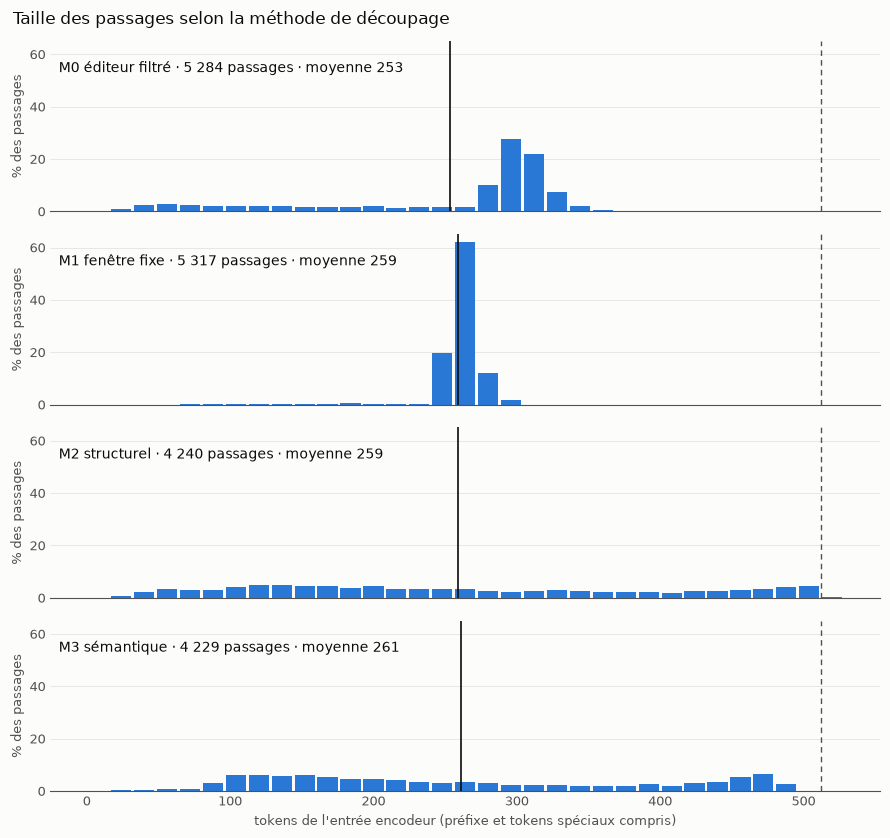

In [31]:
SURFACE, ENCRE, ENCRE_2, SERIE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
fig, axes = plt.subplots(len(METHODES), 1, figsize=(9, 8.5), sharex=True, sharey=True, facecolor=SURFACE)
bords = np.arange(0, BUDGET + 17, 16)
for ax, (nom, P) in zip(axes, METHODES.items()):
    ax.set_facecolor(SURFACE)
    ax.hist(P.n_tokens.clip(upper=BUDGET + 8), bins=bords, weights=np.full(len(P), 100 / len(P)), color=SERIE, rwidth=0.88)
    ax.axvline(P.n_tokens.mean(), color=ENCRE, linewidth=1.2)
    ax.axvline(BUDGET, color=ENCRE_2, linewidth=1, linestyle=(0, (4, 3)))
    ax.text(0.01, 0.84, f"{nom} · {len(P):,} passages · moyenne {P.n_tokens.mean():.0f}".replace(",", " "),
            transform=ax.transAxes, ha="left", va="center", color=ENCRE, fontsize=10,
            bbox={"facecolor": SURFACE, "edgecolor": "none", "pad": 2})
    ax.grid(axis="y", color="#e4e3df", linewidth=0.6)
    ax.set_axisbelow(True)
    for cote in ("top", "right", "left"):
        ax.spines[cote].set_visible(False)
    ax.spines["bottom"].set_color(ENCRE_2)
    ax.tick_params(colors=ENCRE_2, labelsize=9, length=0)
    ax.set_ylabel("% des passages", color=ENCRE_2, fontsize=9)
axes[-1].set_xlabel("tokens de l'entrée encodeur (préfixe et tokens spéciaux compris)", color=ENCRE_2, fontsize=9)
fig.suptitle("Taille des passages selon la méthode de découpage", color=ENCRE, fontsize=12, x=0.02, ha="left")
fig.tight_layout()
plt.show()

**Un même endroit du corpus, vu par chaque méthode.** Fiche « Le bulletin de paie », section « Et les mentions
interdites ? » : le passage de chaque méthode qui contient la phrase sur le droit de grève.

In [32]:
cible_txt = "Aucune mention relative"
for nom, P in METHODES.items():
    ligne = P[(P.pubId == "article374540") & P.texte.str.contains(cible_txt, regex=False)].iloc[0]
    print(f"{nom} · {ligne.n_tokens} tokens")
    k = ligne.texte.find(cible_txt)
    extrait = ("[...] " if k > 120 else "") + ligne.texte[max(0, k - 120):k + 300] + (" [...]" if k + 300 < len(ligne.texte) else "")
    print("   en-tête :", ligne.entete if "entete" in P else ligne.titre_fiche)
    print("   texte   :", extrait.replace("\n", " ⏎ "))
    if "url_citation" in P:
        print("   lien    :", ligne.url_citation)
    print()

M0 éditeur filtré · 89 tokens
   en-tête : Le bulletin de paie
   texte   : Aucune mention relative à l'exercice du droit de grève et à l'activité de représentation des salariés ne doit figurer sur le bulletin de paie :Le non-paiement des heures de grève est traduit par l'intitulé « absence non rémunérée » ;les heures de délégation sont incluses dans le temps de travail nor [...]

M1 fenêtre fixe · 258 tokens
   en-tête : Le bulletin de paie > Documents annexés au bulletin de paie
   texte   : [...] e par voie électronique, dans des conditions de nature à garantir l'intégrité des données. ⏎ Et les mentions interdites ? ⏎ Aucune mention relative à l'exercice du droit de grève et à l'activité de représentation des salariés ne doit figurer sur le bulletin de paie : ⏎ Le non-paiement des heures de grève est traduit par l'intitulé « absence non rémunérée » ; ⏎ - les heures de délégation sont incluses dans le temps de travail [...]
   lien    : https://travail-emploi.gouv.fr/le-bulletin-de-p

**Mots vides : pourquoi le texte est gardé intact.** Aucune méthode ne retire les mots vides, et c'est voulu.
Le texte d'un passage est celui qu'on affiche, qu'on cite et que le lien profond cherche dans la page : il doit
rester intact. Un retrait ne pourrait porter que sur une copie, au moment de l'encodage, et il n'est pas souhaitable
pour l'encodeur e5 :

- le modèle a été entraîné sur du texte naturel, jamais sur du texte privé de ses mots vides ;
- Dai et Callan (SIGIR 2019, tableau 3, collection Robust04) : retirer mots vides et ponctuation des requêtes de
  description (14 mots en moyenne) **dégrade** un modèle BERT (nDCG@20 de 0,529 à 0,503) et **améliore** un modèle
  sac de mots (SDM, de 0,404 à 0,427). C'est un modèle BERT qui reclasse des documents en anglais, pas un encodeur
  comme e5 : une indication, pas une preuve ;
- sur notre corpus, les listes usuelles retirent des mots qui portent le sens juridique : la cellule suivante le
  mesure avec deux listes courantes, celle du projet Snowball (154 mots) et stopwords-iso (691 mots), figées sur
  un commit comme les sources ;
- le gain en tokens ne sert à rien : aucun passage ne dépasse le budget de l'encodeur (tableau de comparaison).

La question ne se pose que pour les références lexicales (TF-IDF, BM25) du notebook 03, où plusieurs variantes
seront comparées sur le jeu de questions.

In [33]:
LISTES_MOTS_VIDES = {
    # liste française du projet Snowball (racinisation) et liste stopwords-iso, figées sur un commit
    "Snowball": {"url": "https://raw.githubusercontent.com/snowballstem/snowball-website/"
                        "5a8cf2451d108217585d8e32d744f8b8fd20c711/algorithms/french/stop.txt",
                 "sha256": "e235f5e633bf831c601ce6f1dc87d8608c038209a7aab64e69a9e70f52f83d4c"},
    "stopwords-iso": {"url": "https://raw.githubusercontent.com/stopwords-iso/stopwords-fr/"
                             "417176f38e0501ecb2861abd64abf86b9b1d9fee/stopwords-fr.txt",
                      "sha256": "a1dd542c70aaae6d08b346e2fb15e886107d4d8b580f4b3dbc96b1d2f42ee0f2"},
}
MOTS_VIDES = {}
for nom, source in LISTES_MOTS_VIDES.items():
    fichier = SOURCES / f"mots_vides_{nom.lower()}.txt"
    obtenir(source, fichier)
    lignes = fichier.read_text(encoding="utf-8").splitlines()
    if nom == "Snowball":
        # un mot en début de ligne, commentaire après une barre verticale ; stopwords-iso n'a pas de commentaire,
        # et sa ligne « o| » doit rester telle quelle
        lignes = [ligne.split("|")[0] for ligne in lignes]
    MOTS_VIDES[nom] = {ligne.strip() for ligne in lignes} - {""}

# mots courts qui changent le sens d'une règle : négation, exception, quantité, temps, modalité
DECISIFS = ["ne", "pas", "sans", "non", "ni", "aucun", "sauf", "plus", "moins", "avant", "après", "pendant",
            "depuis", "entre", "contre", "sous", "sur", "dès", "hors", "seul", "peut", "doit", "pour", "par"]


def normaliser(mot: str) -> str:
    """Forme de comparaison avec les listes : minuscules, apostrophe typographique remplacée par l'apostrophe droite."""
    return mot.lower().replace("’", "'")


def sans_mots_vides(texte: str, liste: set) -> str:
    """Texte privé des mots de la liste, ponctuation et casse conservées, apostrophe d'élision retirée avec son mot (« l' », « n' »)."""
    morceaux = re.split(r"([^\W_]+)", texte)  # alternance séparateur, mot, séparateur, mot...
    for i in range(1, len(morceaux), 2):
        if normaliser(morceaux[i]) in liste:
            morceaux[i] = ""
            if morceaux[i + 1][:1] in ("'", "’"):
                morceaux[i + 1] = morceaux[i + 1][1:]
    return re.sub(r"[ \t]+", " ", "".join(morceaux)).strip()


mots_p2 = [[normaliser(m) for m in RE_MOT.findall(t)] for t in P2.texte]
n_mots = sum(len(m) for m in mots_p2)
tokens_avant = sum(n_tokens_nus(P2.texte))
lignes = []
for nom, liste in MOTS_VIDES.items():
    tokens_apres = sum(n_tokens_nus(sans_mots_vides(t, liste) for t in P2.texte))
    lignes.append({"liste": nom, "mots dans la liste": len(liste),
                   "mots décisifs retirés": sum(w in liste for w in DECISIFS),
                   "part des mots du corpus retirés %": round(100 * sum(w in liste for m in mots_p2 for w in m) / n_mots, 1),
                   "tokens économisés %": round(100 * (1 - tokens_apres / tokens_avant), 1)})
display(pd.DataFrame(lignes).set_index("liste"))
for nom, liste in MOTS_VIDES.items():
    print(f"mots décisifs retirés par {nom} :", ", ".join(w for w in DECISIFS if w in liste))

# estimation par expression régulière : « ne » ou « n' », puis jusqu'à quatre mots, puis le second terme de la négation
negation = P2.texte.str.contains(r"\b(?:ne|n['’])\s?\w+(?:\s+\w+){0,3}\s+(?:pas|plus|jamais|aucun|aucune|que)\b", case=False)
print(f"passages M2 contenant une négation « ne ... pas, plus, jamais, aucun, que » : {negation.sum()} sur {len(P2)} ({100 * negation.mean():.1f} %)")
print("passages contenant", {expr: int(P2.texte.str.contains(rf"\b{expr}\b", case=False).sum())
                             for expr in ("sans", "au moins", "plus de", "moins de")})

# une liste fondée sur la fréquence documentaire retire les mots du domaine eux-mêmes
frequence_doc = Counter(w for m in mots_p2 for w in set(m))
for seuil in (0.5, 0.3, 0.2):
    frequents = [w for w, c in frequence_doc.most_common() if c / len(P2) > seuil]
    hors_listes = [w for w in frequents if all(w not in liste for liste in MOTS_VIDES.values())]
    print(f"mots présents dans plus de {seuil:.0%} des passages : {len(frequents)}, dont hors des deux listes : {hors_listes}")

,mots dans la liste,mots décisifs retirés,part des mots du corpus retirés %,tokens économisés %
liste,,,,
Snowball,154,6,43.4,32.7
stopwords-iso,691,24,52.5,39.0


mots décisifs retirés par Snowball : ne, pas, sans, sur, pour, par
mots décisifs retirés par stopwords-iso : ne, pas, sans, non, ni, aucun, sauf, plus, moins, avant, après, pendant, depuis, entre, contre, sous, sur, dès, hors, seul, peut, doit, pour, par
passages M2 contenant une négation « ne ... pas, plus, jamais, aucun, que » : 1202 sur 4240 (28.3 %)
passages contenant {'sans': 478, 'au moins': 523, 'plus de': 283, 'moins de': 255}
mots présents dans plus de 50% des passages : 20, dont hors des deux listes : ['travail']
mots présents dans plus de 30% des passages : 35, dont hors des deux listes : ['travail', 'employeur', 'code', 'entreprise', 'salariés', 'salarié']
mots présents dans plus de 20% des passages : 55, dont hors des deux listes : ['travail', 'employeur', 'code', 'entreprise', 'salariés', 'salarié', 'cas', 'article', 'contrat', 'emploi', '1', 'durée', 'conditions']


**Des questions de sens différent confondues.** Cinq paires construites à la main : une illustration de l'effet,
pas une mesure de fréquence.

In [34]:
PAIRES = [("Peut-on licencier un salarié pendant son arrêt maladie ?", "Peut-on licencier un salarié après son arrêt maladie ?"),
          ("Licenciement sans cause réelle et sérieuse", "Licenciement pour cause réelle et sérieuse"),
          ("Obligations d'une entreprise de plus de 50 salariés", "Obligations d'une entreprise de moins de 50 salariés"),
          ("Le salarié peut refuser la mutation", "Le salarié ne peut pas refuser la mutation"),
          ("L'employeur doit consulter le CSE avant la décision", "L'employeur doit consulter le CSE après la décision")]
for nom, liste in MOTS_VIDES.items():
    confondues = [(a, b) for a, b in PAIRES if normaliser(sans_mots_vides(a, liste)) == normaliser(sans_mots_vides(b, liste))]
    print(f"{nom} : {len(confondues)} paires sur {len(PAIRES)} deviennent identiques")
    for a, b in confondues:
        print(f"   « {a} » et « {b} » donnent « {sans_mots_vides(a, liste)} »")

Snowball : 2 paires sur 5 deviennent identiques
   « Licenciement sans cause réelle et sérieuse » et « Licenciement pour cause réelle et sérieuse » donnent « Licenciement cause réelle sérieuse »
   « Le salarié peut refuser la mutation » et « Le salarié ne peut pas refuser la mutation » donnent « salarié peut refuser mutation »
stopwords-iso : 5 paires sur 5 deviennent identiques
   « Peut-on licencier un salarié pendant son arrêt maladie ? » et « Peut-on licencier un salarié après son arrêt maladie ? » donnent « - licencier salarié arrêt maladie ? »
   « Licenciement sans cause réelle et sérieuse » et « Licenciement pour cause réelle et sérieuse » donnent « Licenciement cause réelle sérieuse »
   « Obligations d'une entreprise de plus de 50 salariés » et « Obligations d'une entreprise de moins de 50 salariés » donnent « Obligations entreprise 50 salariés »
   « Le salarié peut refuser la mutation » et « Le salarié ne peut pas refuser la mutation » donnent « salarié refuser mutation »


**Pour la soutenance.**

- Des indicateurs intrinsèques : ils décrivent les découpages, sans dire lequel cherche le mieux.
- M2 est la seule méthode dont la référence de section est exacte par construction.
- Les mots vides sont gardés : le texte affiché et cité doit rester intact, et les listes usuelles retirent
  des mots qui changent le sens d'une règle (« ne », « pas », « sans », « avant », « après »).

## 15. Export pour l'indexation

Une table par méthode (M0 à M3, plus la variante M2 à 256 tokens destinée à l'évaluation), au même schéma, dans
`data/decoupage/passages/`, et un manifeste qui fixe tout ce qui
permet de reproduire ou de contrôler l'export : sources et empreintes, révisions du tokeniseur et du modèle,
paramètres, versions des bibliothèques, effectifs, et une empreinte du contenu de chaque table. Deux exécutions
du notebook doivent donner les mêmes empreintes de contenu.

| Colonne | Contenu |
|---|---|
| `passage_id` | identifiant stable dans la table : méthode, fiche, rang |
| `pubId`, `titre_fiche`, `url`, `date_maj` | la fiche source |
| `section_idx`, `section_titre`, `section_origine`, `chemin` | où se trouve le passage dans la fiche |
| `sections_couvertes` | sections traversées (plusieurs possibles pour M1 et M3) |
| `entete`, `texte` | à afficher ; `texte` est le contenu seul |
| `entree_encodeur` | chaîne exacte à encoder, préfixe `passage: ` compris |
| `entree_sans_entete` | variante sans en-tête, pour mesurer l'effet de l'en-tête |
| `n_tokens` | tokens de `entree_encodeur`, tokens spéciaux compris |
| `url_citation` | lien profond par fragment de texte, repli sur l'URL de la fiche |
| `articles` | identifiants LEGIARTI cités dans le passage et résolus par SocialGouv |
| `retranscription` | le passage contient une retranscription de vidéo |

In [35]:
COLONNES = ["passage_id", "methode", "pubId", "titre_fiche", "url", "date_maj", "section_idx", "section_titre",
            "section_origine", "chemin", "sections_couvertes", "entete", "texte", "entree_encodeur",
            "entree_sans_entete", "n_tokens", "url_citation", "articles", "retranscription"]
m0x = m0.assign(url=m0.url, date_maj=m0.doc_id.map(df_fiches.date_maj), section_idx=-1, section_origine="éditeur",
                chemin=[[]] * len(m0), entete=m0.title, entree_sans_entete=PREFIXE + m0.text,
                url_citation=[lien_profond(u, t) for u, t in zip(m0.url, m0.text)],
                articles=[[]] * len(m0), retranscription=False)
EXPORTS = {"m0": m0x, "m1": P1, "m2": P2, "m3": P3}

# variante M2 à 256 tokens au plus, exportée pour mesurer au notebook 03 l'effet du budget ;
# M2 à 512 tokens reste la méthode retenue pour le site
BUDGET_M2_256 = 256
P2_256 = passages_m2(decouper_m2(BUDGET_M2_256, M2_MIN_TOKENS))
P2_256["n_tokens"] = n_tokens(P2_256.entree_encodeur)
assert P2_256.n_tokens.max() <= BUDGET_M2_256, P2_256.n_tokens.max()
EXPORTS["m2_256"] = P2_256
print(f"variante M2 à {BUDGET_M2_256} tokens : {len(P2_256)} passages, tokens moyenne {P2_256.n_tokens.mean():.1f}, max {P2_256.n_tokens.max()}")


def empreinte_contenu(P: pd.DataFrame) -> str:
    """Empreinte SHA-256 du contenu encodable d'une table : identifiants et entrées de l'encodeur, dans l'ordre."""
    h = hashlib.sha256()
    for pid, entree in zip(P.passage_id, P.entree_encodeur):
        h.update(f"{pid}\x1f{entree}\x1e".encode())
    return h.hexdigest()


manifeste = {
    "notebook": "scripts/decoupage/01_corpus_decoupage.ipynb", "execute_le": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "sources": {"socialgouv": SOURCE_SG, "huggingface": SOURCE_HF}, "tokeniseur": TOKENISEUR, "modele_m3": MODELE_M3,
    "parametres": {"BUDGET": BUDGET, "PREFIXE": PREFIXE, "REPARER": REPARER, "GARDER_RETRANSCRIPTIONS": GARDER_RETRANSCRIPTIONS,
                   "M2_MIN_TOKENS": M2_MIN_TOKENS, "M1_CHEVAUCHEMENT": M1_CHEVAUCHEMENT, "M1_W": W_M1,
                   "M3_VOISINAGE": M3_VOISINAGE, "M3_TAU": TAU_M3, "TAILLE_CIBLE": round(CIBLE, 3),
                   "M2_256_BUDGET": BUDGET_M2_256},
    "versions": VERSIONS, "methodes": {},
}
for code, P in EXPORTS.items():
    P = P.copy()
    P["methode"] = code
    P["rang"] = P.groupby("pubId").cumcount()
    P["passage_id"] = [f"{code}-{pid}-{r:04d}" for pid, r in zip(P.pubId, P.rang)]
    P = P[COLONNES].reset_index(drop=True)
    assert P.passage_id.is_unique, code
    assert P.n_tokens.max() <= BUDGET, (code, P.n_tokens.max())
    chemin = SORTIES / f"passages_{code}.parquet"
    P.to_parquet(chemin, index=False, compression="zstd")
    manifeste["methodes"][code] = {"fichier": str(chemin.relative_to(RACINE)), "passages": len(P),
                                   "empreinte_contenu": empreinte_contenu(P), "sha256_fichier": sha256_fichier(chemin)}
    EXPORTS[code] = P
(SORTIES / "manifeste.json").write_text(json.dumps(manifeste, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
display(pd.DataFrame(manifeste["methodes"]).T)

variante M2 à 256 tokens : 7009 passages, tokens moyenne 174.1, max 256


,fichier,passages,empreinte_contenu,sha256_fichier
m0,data/decoupage/passages/passages_m0.parquet,5284,57a6baddaf02268c72a8853b90169cd81ba389daa4e3abcf515560dcecea25ca,2eab5c229066ffadf9337a6704753f299e53e69f5e37eedf9d05deb55650759d
m1,data/decoupage/passages/passages_m1.parquet,5317,3e98557a7268fddd6c92d302054cd869ccfbd20955455610fc5844aa20dd230b,69cea477b66ff234bd21458effad699b438ae555b92bad393367353ac598f265
m2,data/decoupage/passages/passages_m2.parquet,4240,c41868ec369fb5f810119bfa996b5a1b22643d00452cde151901e3f26cf432b0,a7eabb623c9b4bbb7d9625bc86032439d6e90c76ff800de5099b42ecaaab61a4
m3,data/decoupage/passages/passages_m3.parquet,4229,50e41c3ccade54f257320d51e7a48bd77eeae2d6c6fa9071af6f4c7adc90ba1e,00c849bb452f7350925ad331543cbd546a762f85faf274b1780f268a76e48ad7
m2_256,data/decoupage/passages/passages_m2_256.parquet,7009,15144e4ef2568c228546f0ede5a3765d9ef4f7702f077cb1b3b3cb2f02d340d5,b331c17e185a896964135d6e41d3db2ab25503c103840419298f55e73f712db0


**Relecture de l'export.** On relit un fichier écrit et on vérifie qu'il redonne exactement la table en mémoire,
puis on affiche trois passages M2 tirés au hasard, tels que le notebook d'indexation les recevra.

In [36]:
relu = pd.read_parquet(SORTIES / "passages_m2.parquet")
assert relu.drop(columns=["chemin", "sections_couvertes", "articles"]).equals(EXPORTS["m2"].drop(columns=["chemin", "sections_couvertes", "articles"]))
assert all(list(a) == list(b) for a, b in zip(relu.chemin, EXPORTS["m2"].chemin))
print("passages_m2.parquet relu à l'identique :", len(relu), "passages")
for _, r in relu.sample(3, random_state=GRAINE).iterrows():
    print(f"\n{r.passage_id} · {r.n_tokens} tokens · articles {r.articles[:3]}")
    print(r.entree_encodeur[:500])
    print("lien :", r.url_citation)

passages_m2.parquet relu à l'identique : 4240 passages

m2-article378059-0040 · 462 tokens · articles []
passage: L'activité partielle de longue durée (APLD) > Les accords de branche relatifs à l'APLD > Consulter les documents
tallurgie (PDF - 926.97 Ko) Négoce de l'ameublement (PDF - 138.57 Ko) Notariat (PDF - 171.38 Ko) Organismes de tourisme (PDF - 65.72 Ko) Papeterie commerces de détail reprographie (PDF - 659.24 Ko) Personnel des administrateurs et des mandataires judiciaires (PDF - 323.62 Ko) Personnel des prestataires de services dans le domaine du secteur (PDF - 134.66 Ko) Photographie (PDF
lien : https://travail-emploi.gouv.fr/lactivite-partielle-de-longue-duree-apld#:~:text=Consulter%20les%20documents

m2-article112740-0007 · 193 tokens · articles []
passage: Le congé d'adoption > Quelle est la situation à l'issue du congé ?
Dans l'année suivant la rupture de son contrat, le salarié peut solliciter sa réembauche par LRAR ou lettre remise contre récépissé. Il bénéficie alors p

**Pour la soutenance.**

- Une table par méthode, au même schéma, et une entrée d'encodeur déjà composée : le notebook 02 n'a rien à recomposer.
- Le manifeste fixe sources, révisions, paramètres et empreintes ; deux exécutions donnent des fichiers identiques.

## Ce que ce notebook établit, et ce qu'il n'établit pas

**Établi par les cellules ci-dessus :** l'extraction reproduit le texte de SocialGouv (C1 à C3) ; les
filtres de #32 sont transposés et M0 est reproduit à l'identique ; les quatre méthodes produisent des passages
qui tiennent dans le budget de l'encodeur, à taille moyenne égale pour M1, M2 et M3 ; M2 est la seule dont la
référence de section est exacte ; les métadonnées de citation sont attachées à chaque passage ; les mots vides
sont gardés, et la raison est mesurée.

**Non établi :** laquelle de ces méthodes donne la meilleure recherche. Il faut pour cela le jeu de questions
annotées par (URL, extrait de réponse), indépendant du découpage, et une comparaison appariée. Les liens
profonds n'ont été vérifiés qu'à la main, sur 18 liens (section 8) : un contrôle automatique sur un échantillon
plus large reste à faire.